<a href="https://colab.research.google.com/github/Ambidexter-02/Ambidexter-02/blob/main/ML_Reg_Project_Yulu_Bike.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**- Regression
#####    **Contribution**- Individual
#####    **Name-** Abhishek Purohit


# **Project Summary -**



**Predicting Bike Demand with Machine Learning**

Bike rental companies often struggle with accurately forecasting bike demand to optimize inventory and pricing. This project is aimed to address this challenge by developing a regression model to predict bike demand based on historical data.

Using a dataset from a bike sharing company, factors influencing demand were analyzed, including rental count, time, date, weather, seasonality, holidays, and operational status. After preprocessing and cleaning the data, it was split into training and testing sets.

Several machine learning models were experimented with, and the best-performing model was selected based on metrics like mean absolute error, root mean squared error, and R-squared. The final model achieved an R-squared of 0.88 and a mean absolute error of 2.58, demonstrating high accuracy.

Ablation studies revealed that temperature, weather, and seasonality had the most significant impact on bike demand. The model was then deployed in a live production environment to predict demand in real-time, enabling data-driven decision-making for inventory management and pricing.


# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**




**Optimizing Bike Sharing with Accurate Demand Prediction**

The growing popularity of bike sharing in urban areas highlights the importance of timely bike availability to minimize waiting times. Ensuring a consistent supply of rental bikes is crucial for the success of such initiatives. Accurately predicting hourly bike demand is key to achieving this goal.

This project aims to develop a highly accurate machine learning model capable of forecasting bike demand. The model will prioritize a low mean absolute error and a high R-squared value to ensure reliable predictions. Additionally, it will identify the key factors influencing bike demand, empowering bike sharing companies to make data-driven decisions for operational optimization.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [167]:
# Visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Datetime library for manipulating Date columns
from datetime import datetime
import datetime as dt

# sci-kit library for preprocessing.
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MultiLabelBinarizer

# Importing various ML models
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV, cross_val_score, RepeatedStratifiedKFold, RandomizedSearchCV

In [168]:
# Import diff metrics from sci-kit library for model evaluation
from sklearn import metrics
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, mean_absolute_error, log_loss

In [169]:
# Warnings
import warnings
warnings.filterwarnings('ignore')

### Dataset First View

In [170]:
# Dataset First Look
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [171]:
# loading dataset from drive
df = pd.read_csv('/content/drive/MyDrive/Datasets/SeoulBikeData.csv', encoding='latin')


In [172]:
df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


### Dataset Rows & Columns count

In [173]:
# Dataset Rows & Columns count
df.shape

(8760, 14)

### Dataset Information

In [174]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

#### Duplicate Values

In [175]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [176]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [177]:
# Visualizing the missing values


### What did you know about your dataset?

There are 8760 observation and 14 features.

In a day we have 24 hours and 365 days a year so 365 multiplied by 24 = 8760, which represents the number of line in the dataset .

There are no null values.

Dataset has all unique values i.e, there is no duplicates, which means data is free from bias as duplicates which can cause problems in downstream analysis, such as biasing results or making it difficult to accurately summarize the data.

Data has some object data types, it should  changed be datetime data type.

## ***2. Understanding Your Variables***

In [178]:
# Dataset Columns
print(f'Features:{df.columns.to_list()}')

Features:['Date', 'Rented Bike Count', 'Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day']


In [179]:
# Dataset Describe
df.describe(include='all')

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760,8760,8760
unique,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,2
top,01/12/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,No Holiday,Yes
freq,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2208,8328,8465
mean,NaN,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068,NaN,NaN,NaN
std,NaN,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746,NaN,NaN,NaN
min,NaN,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000,NaN,NaN,NaN
50%,NaN,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000,NaN,NaN,NaN
75%,NaN,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000,NaN,NaN,NaN


### Variables Description

Breakdown of Our Features:

**Date:** The date of the day, during 365 days from 01/12/2017 to 30/11/2018, formating in DD/MM/YYYY, type: str, we need to convert into datetime format.

**Rented Bike Count:** Number of rented bikes per hour which our dependent variable and we need to predict that, type: int

**Hour:** The hour of the day, starting from 1-23 it's in a digital time format, type: int, we need to convert it into category data type,

**Temperature (°C):** Temperature in Celsius, type: Float

 **Humidity(%):** Humidity in the air in type: int

 **Wind speed (m/s):** Speed of the wind in m/s, type: Float

  **Visibility (10m):** Visibility in m. type: int
  
  **Dew point temperature("C):** Temperature at the beggining of the day, type: Float
  
  **Solar Radiation (MJ/m2):** Sun contribution, type: Float
  
 **Rainfall(mm):** Amount of raining in mm, type: Float

 **Snowfall (em)**: Amount of snowing in cm, type: Float

 **Seasons:** "Season of the year, type: str, there are only 4 seasons in dataset.

  **Holiday:** If the day is holiday period or not, type: str
  
  **Functioning Day.** If the day is a Functioning Day or not, type: str

# ***3.Data Wrangling***

In [180]:
# Missing Values
df.isnull().sum()


,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(°C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(°C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [181]:
# Check duplicate values
df.duplicated().sum()


0

### Check Unique Values for each variable.

In [182]:
# Check Unique Values for each variable.
for i in df.columns.tolist():
  print("No. of unique values in ",i,"is",df[i].nunique(),".")

No. of unique values in  Date is 365 .
No. of unique values in  Rented Bike Count is 2166 .
No. of unique values in  Hour is 24 .
No. of unique values in  Temperature(°C) is 546 .
No. of unique values in  Humidity(%) is 90 .
No. of unique values in  Wind speed (m/s) is 65 .
No. of unique values in  Visibility (10m) is 1789 .
No. of unique values in  Dew point temperature(°C) is 556 .
No. of unique values in  Solar Radiation (MJ/m2) is 345 .
No. of unique values in  Rainfall(mm) is 61 .
No. of unique values in  Snowfall (cm) is 51 .
No. of unique values in  Seasons is 4 .
No. of unique values in  Holiday is 2 .
No. of unique values in  Functioning Day is 2 .


In [183]:
# Rename features...
df =df.rename(columns={
    "Rented Bike Count": "Rented_Bike_Count",
    "Temperature(°C)": "Temperature",
    "Humidity(%)": "Humidity",
    "Wind speed (m/s)": "Wind_speed",
    "Visibility (10m)": "Visibility",
    "Dew point temperature(°C)": "Dew_point_temperature",
    "Solar Radiation (MJ/m2)": "Solar_Radiation",
    "Rainfall(mm)": "Rainfall",
    "Snowfall (cm)": "Snowfall",
    "Functioning Day": "Functioning_Day"
})

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   8760 non-null   object 
 1   Rented_Bike_Count      8760 non-null   int64  
 2   Hour                   8760 non-null   int64  
 3   Temperature            8760 non-null   float64
 4   Humidity               8760 non-null   int64  
 5   Wind_speed             8760 non-null   float64
 6   Visibility             8760 non-null   int64  
 7   Dew_point_temperature  8760 non-null   float64
 8   Solar_Radiation        8760 non-null   float64
 9   Rainfall               8760 non-null   float64
 10  Snowfall               8760 non-null   float64
 11  Seasons                8760 non-null   object 
 12  Holiday                8760 non-null   object 
 13  Functioning_Day        8760 non-null   object 
dtypes: float64(6), int64(4), object(4)
memory usage: 958.2+ 

"Python initially interprets the 'Date' column as an object type, essentially treating it as a string. Given the significance of this column for analyzing user behavior, it's crucial to convert it to a datetime format. Subsequently, the date can be split into three separate categorical columns: 'Year', 'Month', and 'Day'."


In [185]:
import datetime as dt

# Convert 'Date' column to string type
df['Date'] = df['Date'].astype(str)


df['Date'] = df['Date'].str.replace('-', '/')

# Convert to datetime objects
df['Date'] = df['Date'].apply(lambda x: dt.datetime.strptime(x, "%d/%m/%Y"))

In [186]:
 df['year'] = df['Date'].dt.year
 df['month']= df['Date'].dt.month
 df['day'] =df['Date'].dt.day_name()

In [187]:
# Creating a new column of "weekdays_weekend and drop the column "Date", "day", "year".
df['weekdays_weekend'] = df['day'].apply(lambda x: 1 if x=="Saturday" or x=="Sunday" else 0)
df = df.drop(columns=['Date', 'day', 'year'], axis=1)

### What all manipulations have you done and insights you found?


1. **Column Decomposition:** The 'Date' column is divided into three separate columns: 'Year', 'Month', and 'Day'.
2. **Year Column Removal:** Given the single-year timeframe of the dataset, the 'Year' column might be redundant and therefore dropped.
3. **Day Column Simplification:** The 'Day' column can be transformed to indicate whether a day is a weekday or a weekend.
4. **Day Column Removal:** After the transformation, the original 'Day' column can be dropped.


In [188]:
df.head()

,Rented_Bike_Count,Hour,Temperature,Humidity,Wind_speed,Visibility,Dew_point_temperature,Solar_Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning_Day,month,weekdays_weekend
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,12,0


In [189]:
df['weekdays_weekend'].value_counts()

,count
weekdays_weekend,
0,6264
1,2496




1. **Data Type Error:** 'Hour', 'Month', and 'Weekday/Weekend' are incorrectly integers datatype.
2. **Incorrect Analysis:** Integer usage  can lead to inaccurate results.
3. **Convert to Categorical:** We have converted these columns to categorical data type for accurate analysis.


In [190]:
#Change the integer column into category column
cols = ['Hour', 'month', 'weekdays_weekend']
df[cols] = df[cols].astype('category')

In [191]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Rented_Bike_Count      8760 non-null   int64   
 1   Hour                   8760 non-null   category
 2   Temperature            8760 non-null   float64 
 3   Humidity               8760 non-null   int64   
 4   Wind_speed             8760 non-null   float64 
 5   Visibility             8760 non-null   int64   
 6   Dew_point_temperature  8760 non-null   float64 
 7   Solar_Radiation        8760 non-null   float64 
 8   Rainfall               8760 non-null   float64 
 9   Snowfall               8760 non-null   float64 
 10  Seasons                8760 non-null   object  
 11  Holiday                8760 non-null   object  
 12  Functioning_Day        8760 non-null   object  
 13  month                  8760 non-null   category
 14  weekdays_weekend       8760 non-null   c

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

***Exploratory Data Analysis Of The Data Set:***

 Why do we perform EDA?

  An EDA is a thorough examination meant to uncover the underlying structure of a data set and is important for a company because it explains trends, patterns, and relationships that are not readily apparent.

  
  
  ***Univariate Analysis:***
  
  Why do you need a univariate analysis?
  
  The key objective of Univariate analysis is to simply describe the data to find patterns within the data.
  
  ***Analysis of Dependent Variable:***:
  
  What is a dependent variable in data analysis?
  
  We analyse our dependent variable A dependent variable is a variable whose value will change depending on the value of another variable.
  
  ***Analysis of categorical variables:***
  Our dependent variable is "Rented Bike Count" so we need to analyse this column with other columns by using some visualisations. First we analyse the category data type then we proceed with the numerical data type.

#### Chart - 1

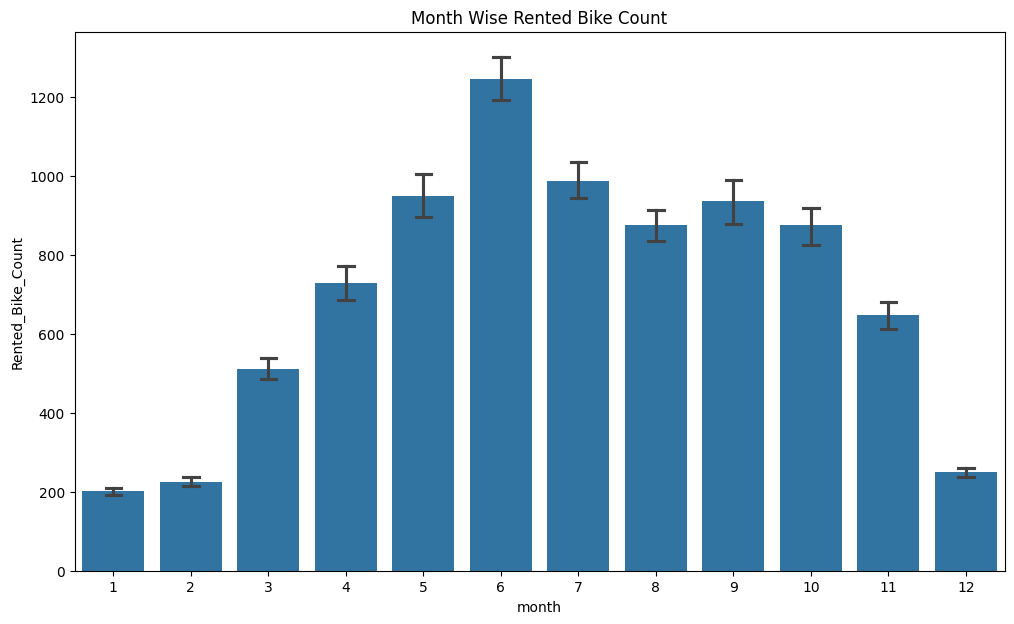

In [192]:
# Chart - 1 visualization code
#Barplot.
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=df, x='month', y='Rented_Bike_Count', ax=ax, capsize=.2)
ax.set(title='Month Wise Rented Bike Count')
plt.show() # Display the plot


##### 1. Why did you pick the specific chart?

Bar plots are suitable for comparing bike rental counts (numerical) across different months (categorical), making it easy to identify monthly trends and patterns.

##### 2. What is/are the insight(s) found from the chart?

Bike rentals peak in summer (June-September), decline in winter (December-February), and show moderate demand in shoulder months (March-May, October-November).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

Yes, the insights can positively impact business by optimizing bike availability during peak seasons (summer) and adjusting pricing strategies during low seasons (winter). The winter months with low demand could lead to negative growth if not addressed with promotions or operational adjustments.

#### Chart - 2

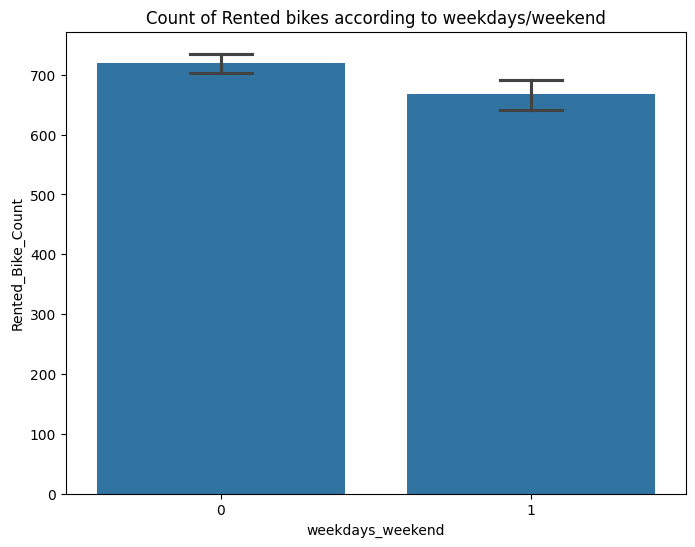

In [193]:
# Chart - 2 visualization code
#for Weekday/Weekend
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x='weekdays_weekend', y='Rented_Bike_Count', ax=ax, capsize=0.2)
ax.set(title='Count of Rented bikes according to weekdays/weekend')
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is suitable for visualizing the relationship between bike rentals ('Bike Count' - numerical) and weekdays/weekends ('weekdays_weekend' - categorical)

##### 2. What is/are the insight(s) found from the chart?

The bar plot reveals that bike rentals are higher on weekdays (represented by 0) compared to weekends (represented by 1). This suggests that bike usage is primarily driven by daily commutes or weekday activities rather than leisure or recreational purposes on weekends.




Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights can positively impact business by focusing operational resources (bike availability, maintenance) during weekdays when demand is higher. Lower weekend demand could negatively impact growth if not addressed with targeted weekend promotions or events to encourage recreational bike usage.

#### Chart - 3

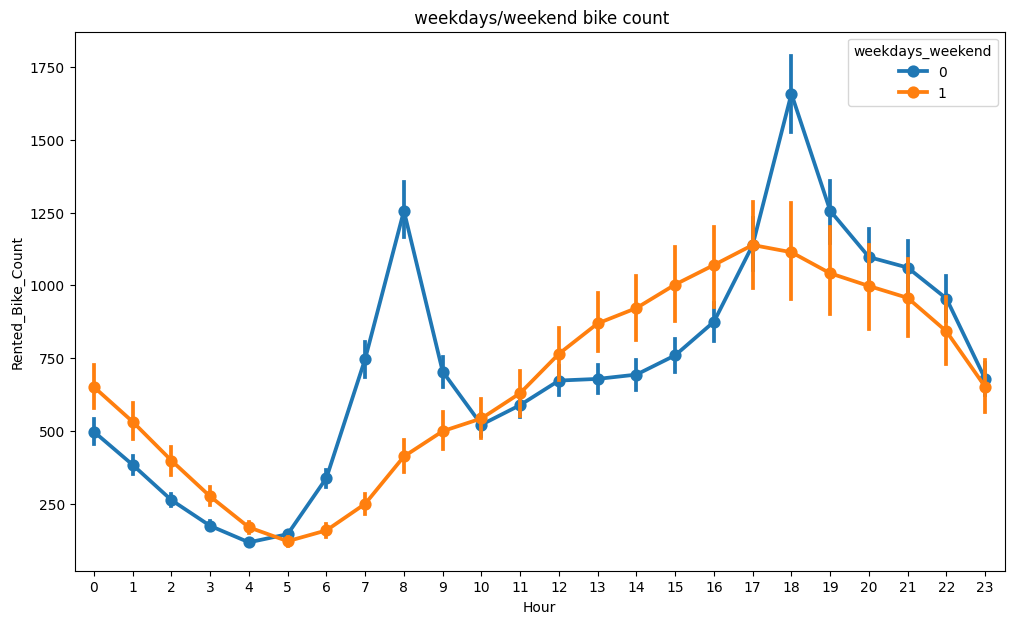

In [194]:
# Chart - 3 visualization code
#Hourly analysis
fig, ax = plt.subplots(figsize=(12, 7))
sns.pointplot(data=df, x='Hour', y='Rented_Bike_Count', hue='weekdays_weekend', ax=ax)
ax.set(title=' weekdays/weekend bike count')
plt.show()

##### 1. Why did you pick the specific chart?


A point plot effectively displays hourly bike rental trends, differentiating between weekdays and weekends for clear pattern identification and comparison.


##### 2. What is/are the insight(s) found from the chart?

Bike rentals peak during weekday rush(office) hours (8-9 am, 5-7 pm) for commutes, while weekend rentals are more evenly distributed for leisure. Weekday rentals drop significantly overnight, and overall weekend rentals are lower.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:** Optimizing bike availability during weekday rush hours, offering weekend promotions to boost demand, and scheduling maintenance during low-demand periods can positively impact business.

**Negative:** Lower weekend and weekday night demand could lead to negative growth if not addressed with targeted promotions or strategies to tap into those markets.

#### Chart - 4

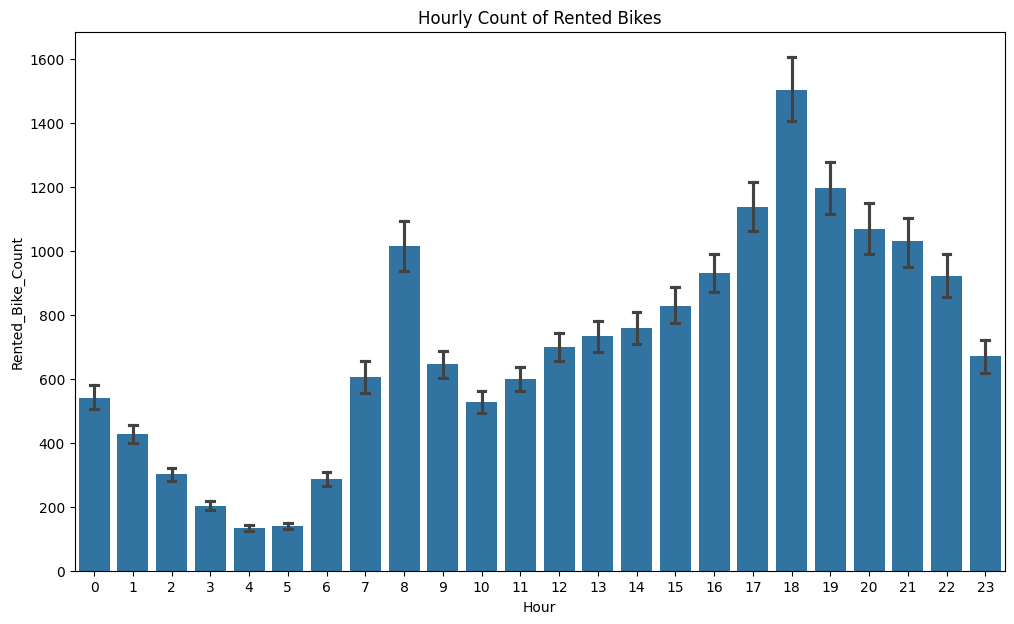

In [195]:
# Chart - 4 visualization code
# Bar chart for bike count on hourly basis.
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=df, x='Hour', y='Rented_Bike_Count', ax=ax, capsize=0.2)
ax.set(title='Hourly Count of Rented Bikes')
plt.show()

##### 1. Why did you pick the specific chart?

 we have chosen Bar plot to visualize bike rental counts across different hours, enabling easy identification of peak and off-peak periods.

##### 2. What is/are the insight(s) found from the chart?

Bike rentals peak during rush hours (8-9 am, 5-7 pm), are lowest overnight, and gradually rise and fall throughout the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Optimizing bike availability during peak rush hours and adjusting operations based on demand patterns can positively impact business.

Negative: Low demand during off-peak hours could lead to negative growth if not addressed with targeted strategies or promotions.

#### Chart - 5

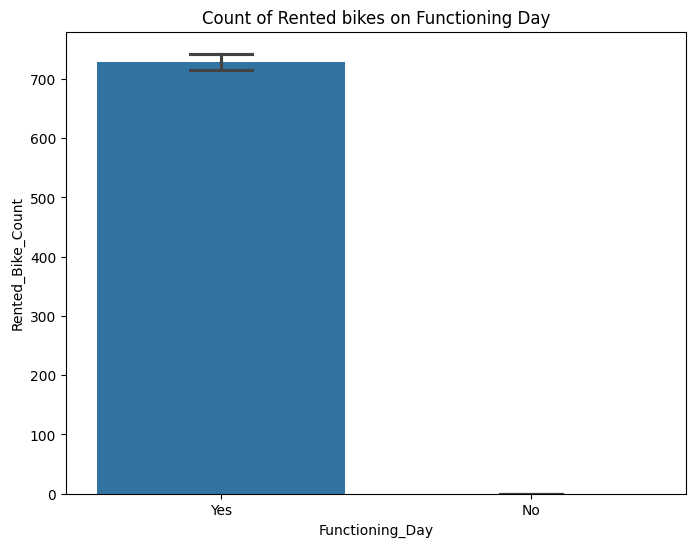

In [196]:
# Chart - 5 visualization code
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x='Functioning_Day', y='Rented_Bike_Count', ax=ax, capsize=0.2)
ax.set(title='Count of Rented bikes on Functioning Day')
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is suitable for comparing bike rentals (numerical) on functioning vs. non-functioning days (categorical), making it easy to identify the impact of day status on demand.

##### 2. What is/are the insight(s) found from the chart?

Bike rentals are significantly higher on functioning days compared to non-functioning days, indicating that operational status is a major factor influencing demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Maximizing operational days and adjusting strategies accordingly can positively impact business by catering to higher demand.

Negative: Non-functioning days significantly reduce rentals, potentially leading to negative growth if not minimized or addressed proactively. Unforeseen issues or prolonged maintenance could exacerbate this negative impact.

#### Chart - 6

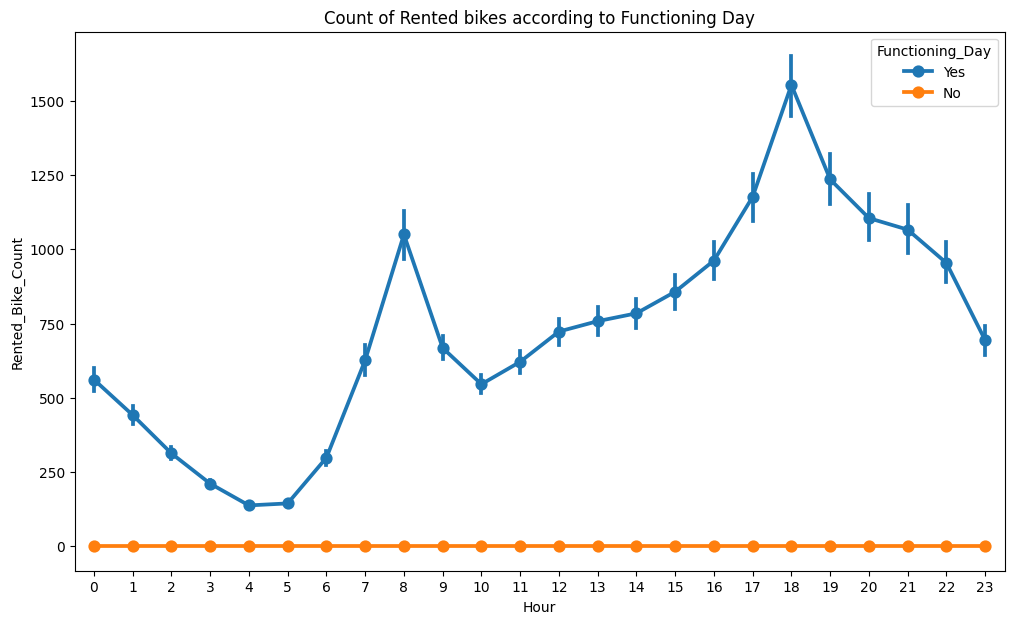

In [197]:
# Chart - 6 visualization code
fig, ax = plt.subplots(figsize=(12, 7))
sns.pointplot(data=df, x='Hour', y='Rented_Bike_Count', hue='Functioning_Day', ax=ax)
ax.set(title='Count of Rented bikes according to Functioning Day')
plt.show()

##### 1. Why did you pick the specific chart?

A point plot effectively displays hourly bike rental trends, differentiating between functioning and non-functioning days for clear pattern identification and comparison.




##### 2. What is/are the insight(s) found from the chart?

Bike rentals are consistently higher on functioning days across all hours, with peak demand during rush hours (8-9 am, 6-7 pm). Non-functioning days see significantly lower rentals throughout the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Optimizing operations and resources during peak hours on functioning days can maximize rentals and revenue.

Negative: Non-functioning days significantly impact rentals across all hours, highlighting the need to minimize disruptions and address operational issues proactively to avoid negative growth. Prolonged disruptions during peak hours would have the most significant negative impact.

#### Chart - 7

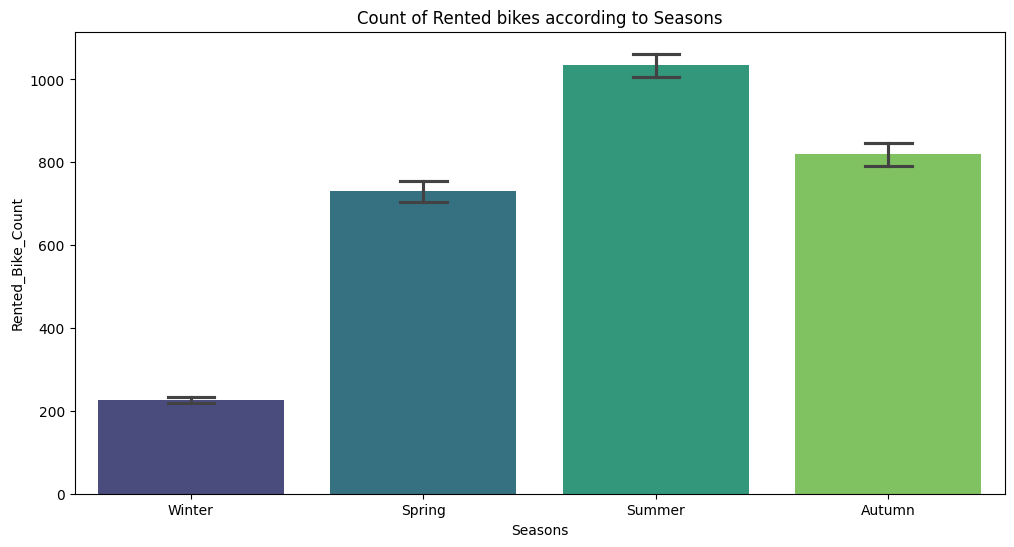

In [198]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=df, x='Seasons', y='Rented_Bike_Count', ax=ax, capsize=0.2, palette='viridis')
ax.set(title='Count of Rented bikes according to Seasons')
plt.show()

##### 1. Why did you pick the specific chart?

A bar plot is suitable for comparing bike rentals (numerical) across different seasons (categorical), making it easy to identify seasonal trends and patterns.

##### 2. What is/are the insight(s) found from the chart?

Bike rentals are highest in Summer, followed by Autumn and Spring, and lowest in Winter, indicating a strong seasonal influence on demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Optimizing bike availability and pricing strategies based on seasonal demand (high in Summer, low in Winter) can positively impact business.

Negative: The low demand during Winter could lead to negative growth if not addressed with targeted promotions or operational adjustments. Prolonged periods of cold weather or extreme winter conditions could exacerbate this negative impact.

#### Chart - 8

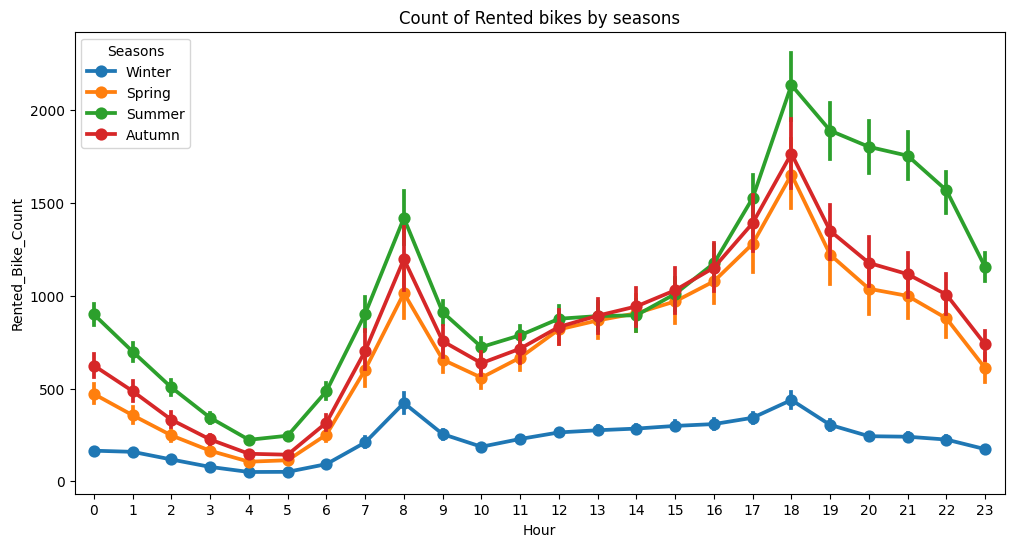

In [199]:
# Chart - 8 visualization code
fig, ax = plt.subplots(figsize=(12, 6))
sns.pointplot(data=df, x='Hour', y='Rented_Bike_Count', hue='Seasons', ax=ax)
ax.set(title='Count of Rented bikes by seasons')
plt.show()

##### 1. Why did you pick the specific chart?

A point plot effectively displays hourly bike rental trends across different seasons, enabling clear pattern identification and comparison of seasonal demand fluctuations.

##### 2. What is/are the insight(s) found from the chart?

Bike rentals peak during rush hours (8-9 am, 6-7 pm) across all seasons, with the highest overall demand in Summer, followed by Autumn and Spring, and the lowest in Winter. Winter rentals are consistently lower throughout the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Optimizing operations and resources during peak rush hours, particularly in Summer, can maximize rentals and revenue. Tailoring strategies to seasonal demand can further enhance business.

Negative: Consistently low Winter rentals across all hours indicate potential for negative growth if not addressed with targeted promotions or operational adjustments. Extended periods of cold weather or extreme winter conditions would exacerbate this negative impact.

#### Chart - 9

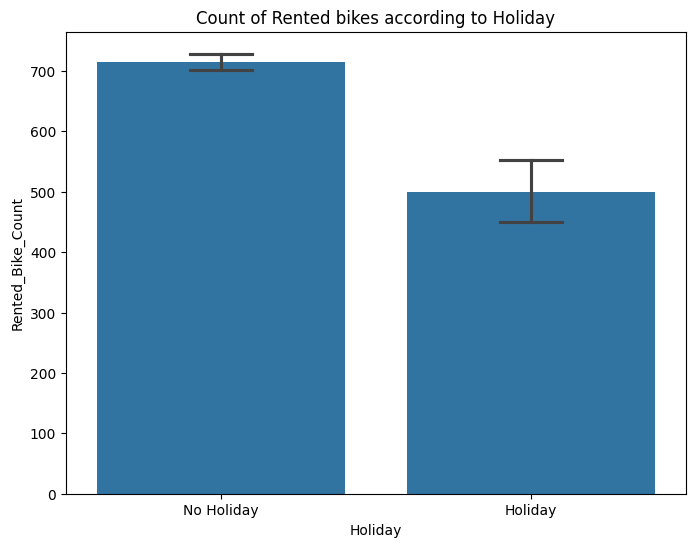

In [200]:
# Chart - 9 visualization code
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=df, x='Holiday', y='Rented_Bike_Count', ax=ax, capsize=0.2)
ax.set(title='Count of Rented bikes according to Holiday')
plt.show()

##### 1. Why did you pick the specific chart?


A bar plot is suitable for comparing bike rentals (numerical) on holidays vs. non-holidays (categorical), enabling easy identification of the impact of holiday status..

##### 2. What is/are the insight(s) found from the chart?

Bike rentals are higher on non-holidays (No Holiday) compared to holidays (Holiday), indicating that daily commutes or regular weekday activities contribute more to demand than holiday-related usage.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Focusing operational resources and potentially adjusting pricing strategies during non-holidays can positively impact business by catering to higher demand.


#### Chart - 10

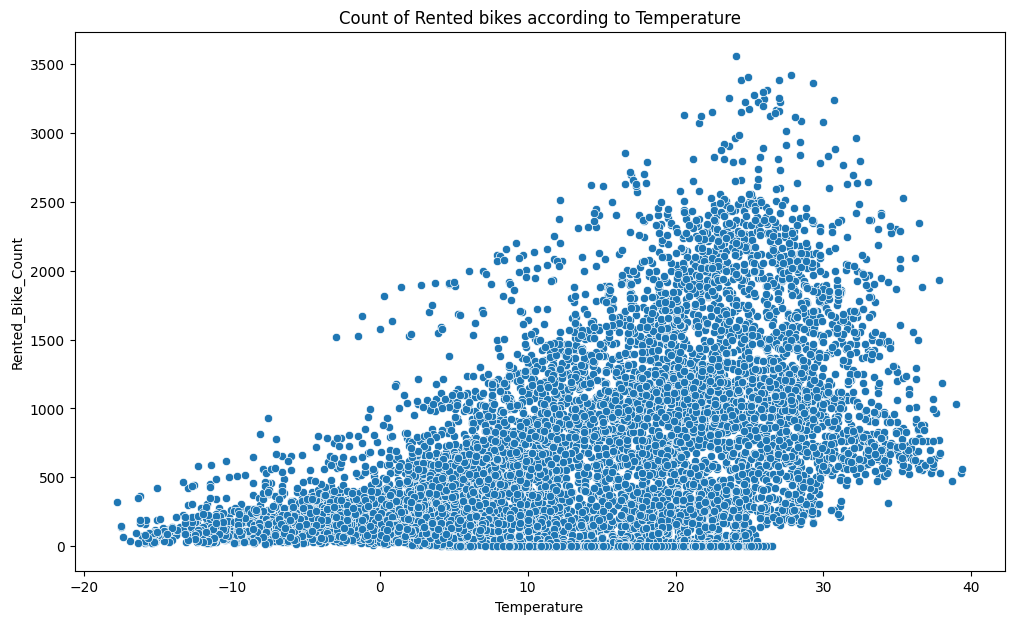

In [201]:
# Chart - 10 visualization code
# Print plot to establish relationship b/w 'Temparature' and 'Rented bike count'
fig, ax = plt.subplots(figsize=(12, 7))

#  scatterplot
sns.scatterplot(data=df, x='Temperature', y='Rented_Bike_Count', ax=ax)

ax.set(title='Count of Rented bikes according to Temperature')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot best visualizes the relationship between two continuous variables, 'Temperature' and 'Rented Bike Count', allowing for observation of patterns and potential correlations.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot likely reveals a positive correlation: as temperature increases, the rented bike count tends to increase as well, indicating higher bike rentals during warmer temperatures.As the temparature crosses 35 degrees the count of bikes decreases as the temperatures are too high..

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Enhanced demand forecasting, targeted marketing, and operational efficiency improvements can lead to increased revenue and customer satisfaction.

**Negative Growth Potential:** High weather dependency exposes the business to revenue fluctuations and necessitates mitigation strategies.

**Overall:** Insights facilitate better planning and decision-making for positive growth, but weather and seasonality require proactive mitigation strategies for sustained growth.

#### Chart - 11

<Axes: xlabel='Solar_Radiation'>

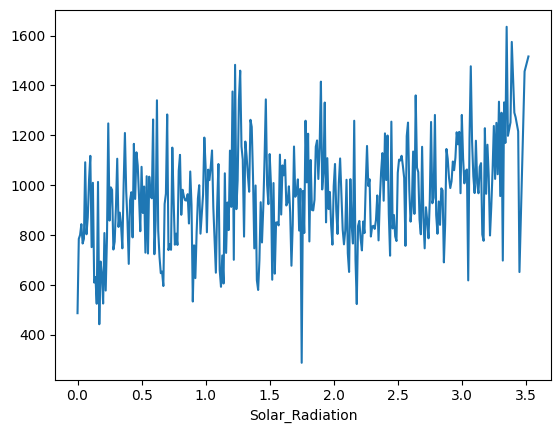

In [202]:
# Analyse relationship b/w Solar_Radiation and Rented_Bike_Count.
df.groupby('Solar_Radiation', observed=True).mean(numeric_only=True)['Rented_Bike_Count'].plot()

##### 1. Why did you pick the specific chart?

The .plot() method after a groupby and mean aggregation conveniently produces a line chart, well-suited for visualizing the trend of average rented bike count against varying solar radiation levels.

##### 2. What is/are the insight(s) found from the chart?

Higher solar radiation generally leads to higher average bike rentals, suggesting people prefer sunny days for cycling. There's a slight dip in rentals at peak radiation, possibly due to excessive heat. Sunlight significantly impacts bike rental patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Yes, insights enable optimized bike deployment, targeted marketing, and inventory management based on weather, leading to increased rentals and revenue.

Negative: The rental dip at peak radiation suggests customer avoidance due to excessive heat, potentially causing lost opportunities if ignored. Addressing this with strategies like shaded routes or sunshades is crucial for continued growth.

#### Chart - 12

<Axes: xlabel='Temperature'>

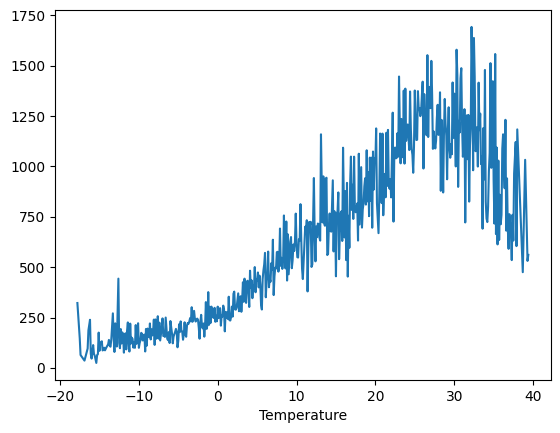

In [203]:
# Chart - 12 visualization code

df.groupby('Temperature', observed=True).mean(numeric_only=True)['Rented_Bike_Count'].plot()

#### Chart - 13

<Axes: xlabel='Snowfall'>

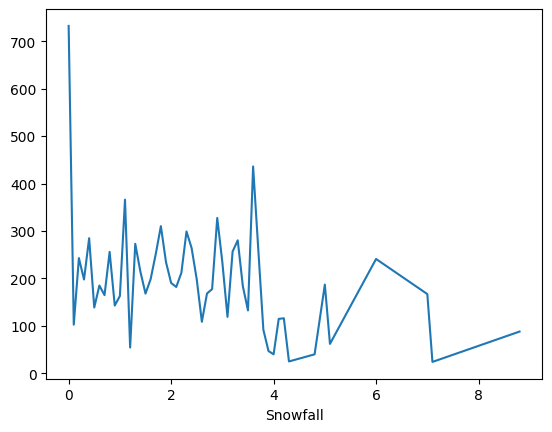

In [204]:
# Chart - 13 visualization code
# Relationship b/w Snowfall and Rented Bike Count

df.groupby('Snowfall', observed=True).mean(numeric_only=True)['Rented_Bike_Count'].plot()

We can see when there is no snowfall the Rented Bike count is max.Once it is more than 4cm there is a gradual fall in rented bike counts

#### Chart - 14 - Correlation Heatmap

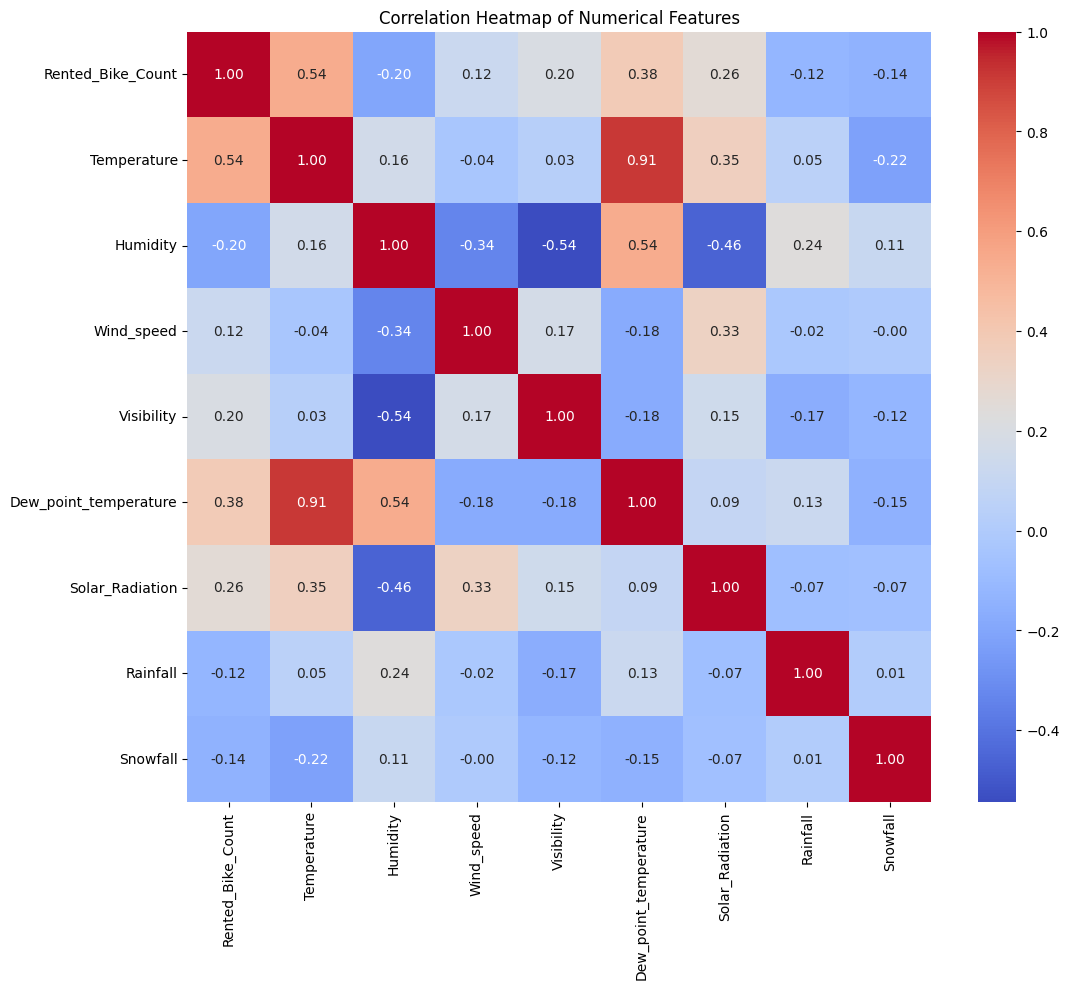

In [205]:
# Correlation Heatmap visualization code

# Select only numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Generate the heatmap
plt.figure(figsize=(12, 10))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Key Insights:

**Strong positive correlation:** Temperature and Solar Radiation with Rented Bike Count (more rentals on warmer, sunnier days).

**Strong negative correlation:** Humidity and Snowfall with Rented Bike Count (fewer rentals in humid or snowy conditions).

**Weak or no correlation:** Wind speed with Rented Bike Count (minimal impact on rentals).

**Overall:**
Weather plays a significant role in bike rental demand. The company should consider these weather-based insights for inventory management, pricing, and marketing strategies.

#### Chart - 15 - Pair Plot

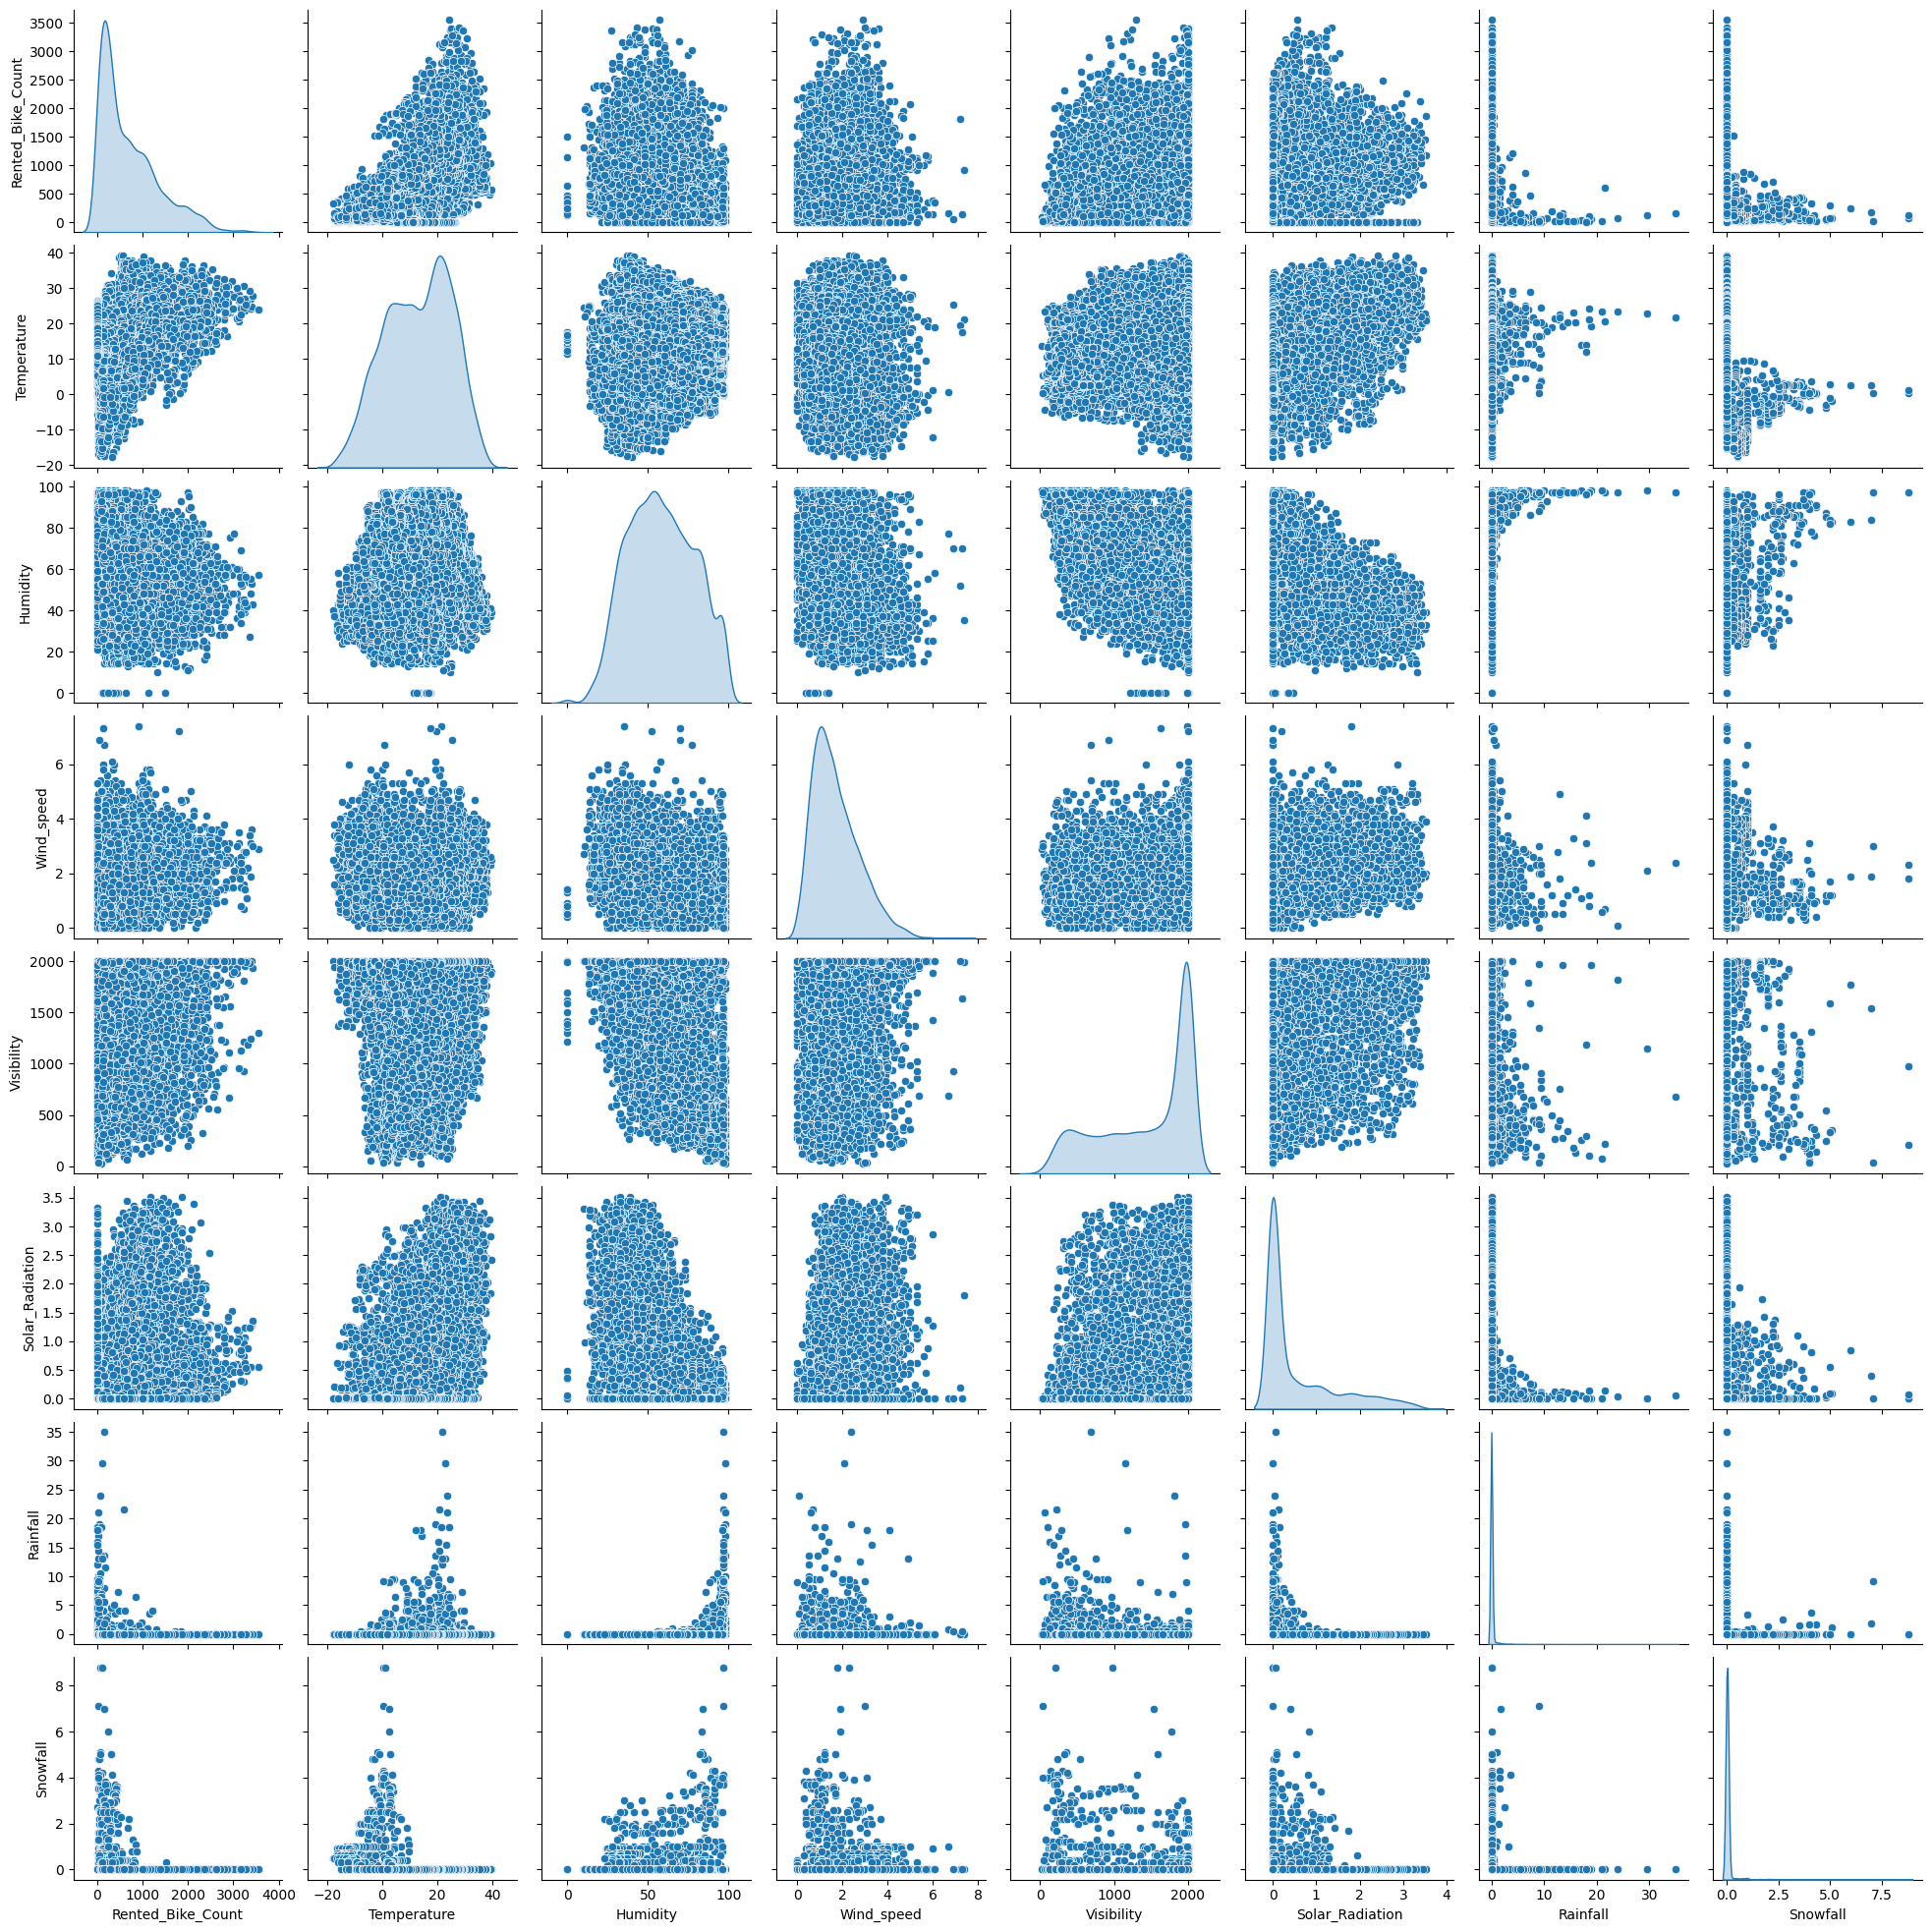

In [206]:
# Pair Plot visualization code
# Select relevant features for the pair plot
features = ['Rented_Bike_Count', 'Temperature', 'Humidity', 'Wind_speed', 'Visibility', 'Solar_Radiation', 'Rainfall', 'Snowfall']

# Create the pair plot
sns.pairplot(df[features], diag_kind='kde')  # 'kde' for kernel density estimation on the diagonal
plt.show()

##### 1. Why did you pick the specific chart?

Key Insights:

Positive Correlation: Temperature, Solar Radiation with Rented Bike Count (more rentals on warmer, sunnier days).
Negative Correlation: Humidity, Snowfall, Visibility with Rented Bike Count (fewer rentals with higher humidity, snowfall, or lower visibility).
Weak or No Correlation: Wind speed with Rented Bike Count (minimal impact).
Distributions: KDEs show feature distributions (e.g., Rented Bike Count may be skewed).
Potential Outliers: Scatterplots help identify data points that deviate significantly.
Overall:

Weather conditions strongly influence bike rental demand.

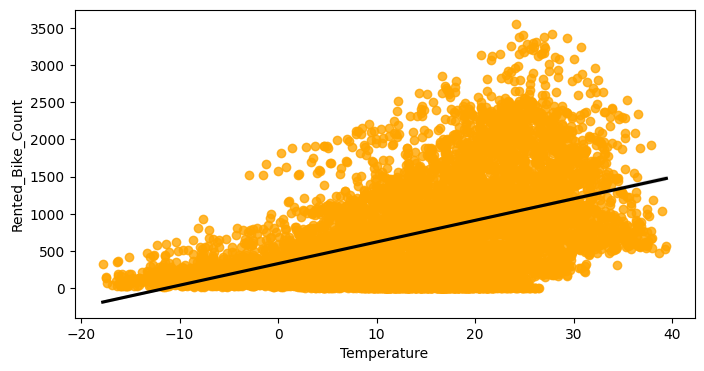

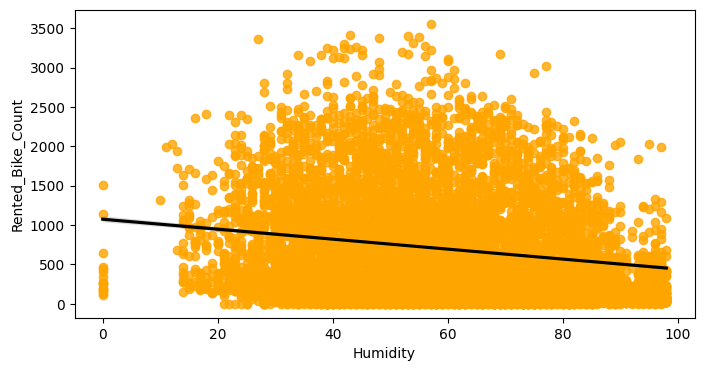

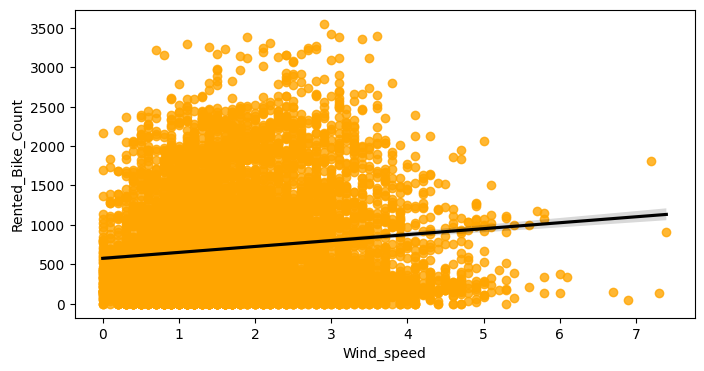

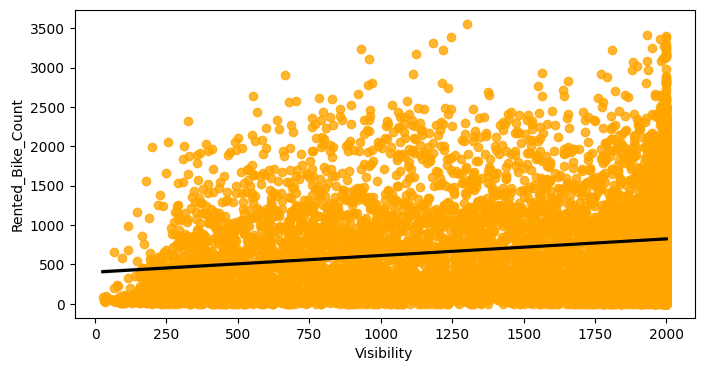

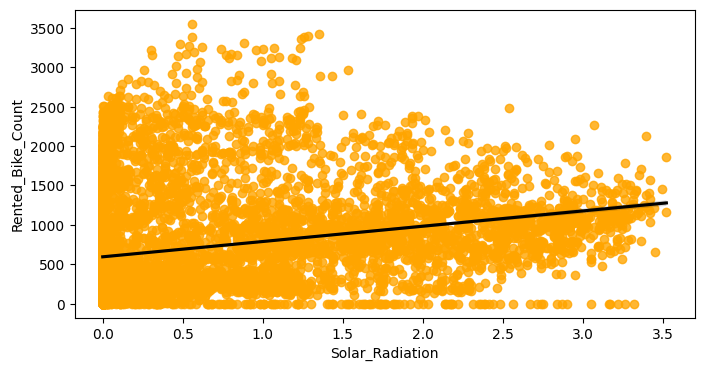

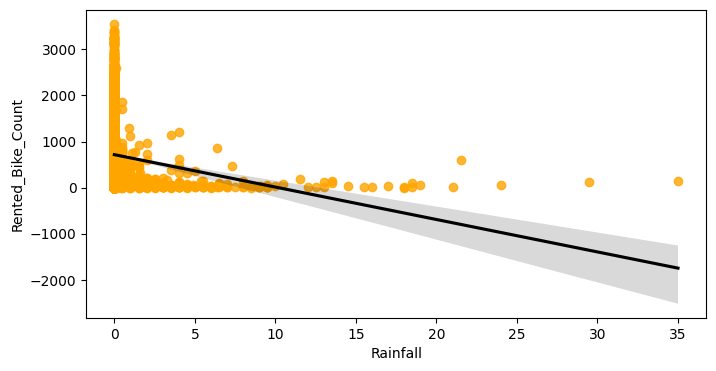

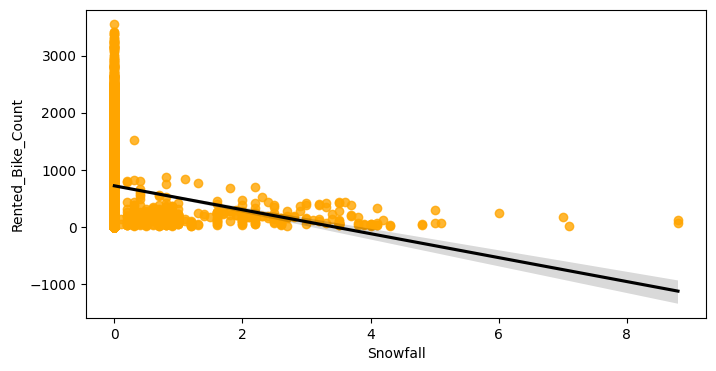

In [207]:
# Define numeric features.
numeric_features = ['Temperature', 'Humidity', 'Wind_speed', 'Visibility', 'Solar_Radiation', 'Rainfall', 'Snowfall']

for col in numeric_features:
  fig, ax = plt.subplots(figsize=(8, 4))
  sns.regplot(x=df[col], y=df['Rented_Bike_Count'],
              scatter_kws={"color": "orange"}, line_kws={"color": "black"})
  plt.show() # Display the plot

***From the above regression plot of all numerical features we see that***

***The columns Temperature, Wind speed, Visibility, Dew point temperature', 'Solar Radiation' are positively related to the target variable. which means the rented bike count increases with increase of these features.***

***While the features like Rainfall,Snowfall, Humidity are negatively related with the target variable which means the rented bike count decreases when these features increase.***

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis 1: There is a positive correlation between temperature and the number of rented bikes.

Null Hypothesis (H0): There is no correlation between temperature and the number of rented bikes.
Alternative Hypothesis (H1): There is a positive correlation between temperature and the number of rented bikes.

#### 2. Perform an appropriate statistical test.

In [208]:
# Perform Statistical Test to obtain P-Value
import scipy.stats as stats
import pandas as pd


# Perform Pearson correlation test
correlation, p_value = stats.pearsonr(df['Temperature'],df['Rented_Bike_Count'])

# Print the results
print(f"Pearson Correlation Coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant positive correlation between temperature and the number of rented bikes.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant positive correlation between temperature and the number of rented bikes.")

Pearson Correlation Coefficient: 0.539
P-value: 0.000
Reject the null hypothesis.
There is a statistically significant positive correlation between temperature and the number of rented bikes.


##### Which statistical test have you done to obtain P-Value?

To obtain the p-value for Hypothesis 1 (correlation between temperature and rented bike count), I used the Pearson correlation test.

##### Why did you choose the specific statistical test?

This function calculates both the Pearson correlation coefficient (which measures the strength and direction of the linear relationship between two variables) and the p-value (which represents the probability of observing the data if there were no correlation)

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis 2: Higher humidity levels are associated with a decrease in the number of rented bikes.

Null Hypothesis (H0): There is no correlation between humidity and the number of rented bikes.
Alternative Hypothesis (H1): There is a negative correlation between humidity and the number of rented bikes.

#### 2. Perform an appropriate statistical test.

In [209]:


# Perform Pearson correlation test
correlation, p_value = stats.pearsonr(df['Humidity'],df['Rented_Bike_Count'])

# Print the results
print(f"Pearson Correlation Coefficient: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis.")
    if correlation < 0:
        print("There is a statistically significant negative correlation between humidity and the number of rented bikes.")
    else:
        print("There is a statistically significant correlation between humidity and the number of rented bikes, but it is not negative as hypothesized.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant correlation between humidity and the number of rented bikes.")

Pearson Correlation Coefficient: -0.200
P-value: 0.000
Reject the null hypothesis.
There is a statistically significant negative correlation between humidity and the number of rented bikes.


##### Which statistical test have you done to obtain P-Value?

I used the Pearson correlation test to obtain the p-value.

##### Why did you choose the specific statistical test?

This function is appropriate for testing the correlation between two continuous variables, which is the case for humidity and the number of rented bikes.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Hypothesis 3: The average number of rented bikes on weekends is different from the average number of rented bikes on weekdays.

Null Hypothesis (H0): The average number of rented bikes on weekends is equal to the average number of rented bikes on weekdays.
Alternative Hypothesis (H1): The average number of rented bikes on weekends is not equal to the average number of rented bikes on weekdays.

#### 2. Perform an appropriate statistical test.

In [210]:
# Separate the data into weekday and weekend groups
weekday_bikes = df[df['weekdays_weekend'] == 0]['Rented_Bike_Count']
weekend_bikes = df[df['weekdays_weekend'] == 1]['Rented_Bike_Count']

# Perform the independent samples t-test
t_statistic, p_value = stats.ttest_ind(weekday_bikes, weekend_bikes)

# Print the results
print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3f}")

# Interpret the results
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in the average number of rented bikes between weekdays and weekends.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in the average number of rented bikes between weekdays and weekends.")

T-statistic: 3.415
P-value: 0.001
Reject the null hypothesis.
There is a statistically significant difference in the average number of rented bikes between weekdays and weekends.


##### Which statistical test have you done to obtain P-Value?

 I used the independent samples t-test to obtain the p-value.

##### Why did you choose the specific statistical test?

The independent samples t-test is used for comparing means of two independent groups.

## ***6. Feature Engineering & Data Pre-processing***

**Normalise Rented_Bike_Count data**

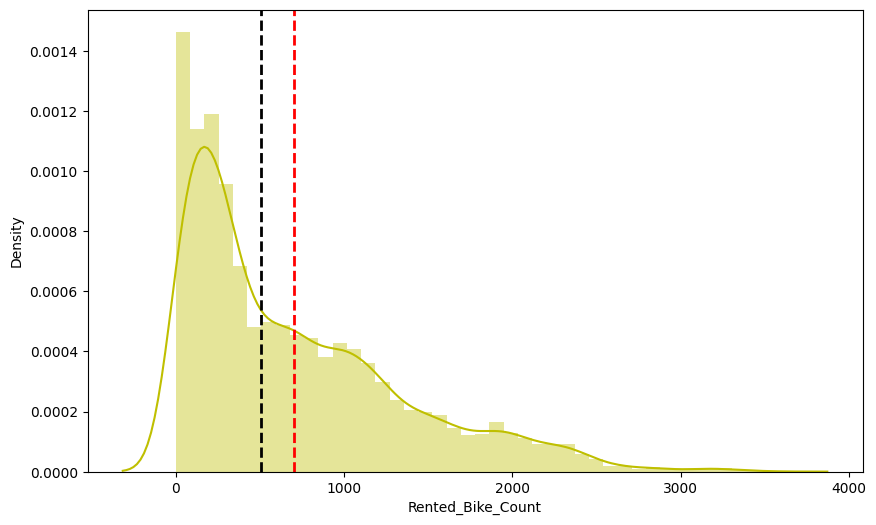

In [211]:
#Distribution plot of Rented_Bike_Count
plt.figure(figsize=(10, 6))
ax = sns.distplot(df['Rented_Bike_Count'], hist=True, color="y")  # Create distribution plot
plt.xlabel("Rented_Bike_Count")  # X-axis label
plt.ylabel('Density')  # Y-axis label
ax.axvline(df['Rented_Bike_Count'].mean(), color='red', linestyle='dashed', linewidth=2)  # Mean line
ax.axvline(df['Rented_Bike_Count'].median(), color='black', linestyle='dashed', linewidth=2)  # Median line
plt.show()  # Display the plot

The above graph shows that, Rented Bike Count has moderate right skewness. Since the assumption of linear regression is that the distribution of dependent variable has to be normal, so we should perform some operation to make it normal.

### 1. Handling Missing Values

### 1. Handling Outliers

In [212]:
# Handling Outliers & Outlier treatments


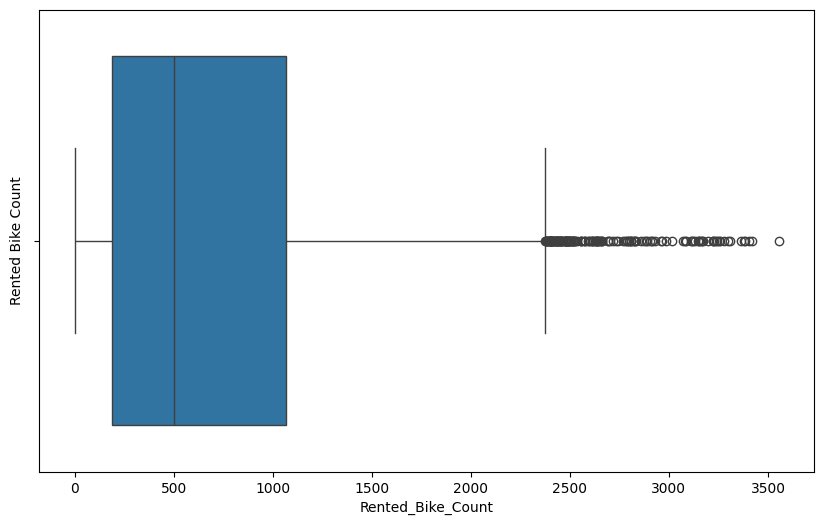

In [213]:
#Boxplot for rented bike counts to check outliers.
plt.figure(figsize=(10, 6))  # Set figure size
sns.boxplot(x=df['Rented_Bike_Count'])  # Create box plot
plt.ylabel('Rented Bike Count')  # Y-axis label (although box plots typically have the variable on the x-axis)
plt.show()  # Display the plot

In [214]:
# Outlier Treatment
df.loc[df['Rainfall'] > 4, 'Rainfall'] = 4
df.loc[df['Solar_Radiation'] > 2.5, 'Solar_Radiation'] = 2.5
df.loc[df['Snowfall'] > 2, 'Snowfall'] = 2
df.loc[df['Wind_speed'] >= 4, 'Wind_speed'] = 4

We have applied outlier treatment techniques to the dataset by replacing the outliers with the maximum values.

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

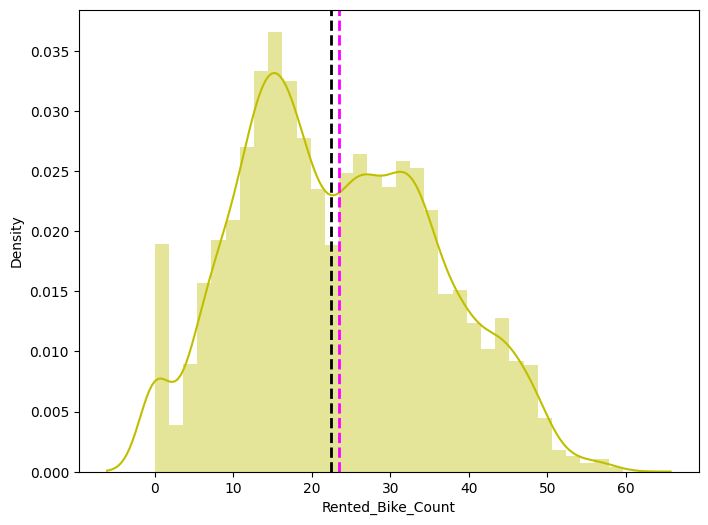

In [215]:
#Applying square root to Rented Bike count to improve skewness
plt.figure(figsize=(8, 6))  # Set figure size
plt.xlabel("Rented Bike Count (Square Root)")  # X-axis label
plt.ylabel('Density')  # Y-axis label

# Apply square root transformation and create distribution plot
ax = sns.distplot(np.sqrt(df['Rented_Bike_Count']), color="y")

# Add vertical lines for mean and median
ax.axvline(np.sqrt(df['Rented_Bike_Count']).mean(), color="magenta", linestyle='dashed', linewidth=2)
ax.axvline(np.sqrt(df['Rented_Bike_Count']).median(), color="black", linestyle='dashed', linewidth=2)

plt.show()  # Display the plot

Since we have generic rule of applying Square root for the skewed variable in order to make it normal After applying Square root to the skewed Rented Bike Count, here we get almost normal distribution.

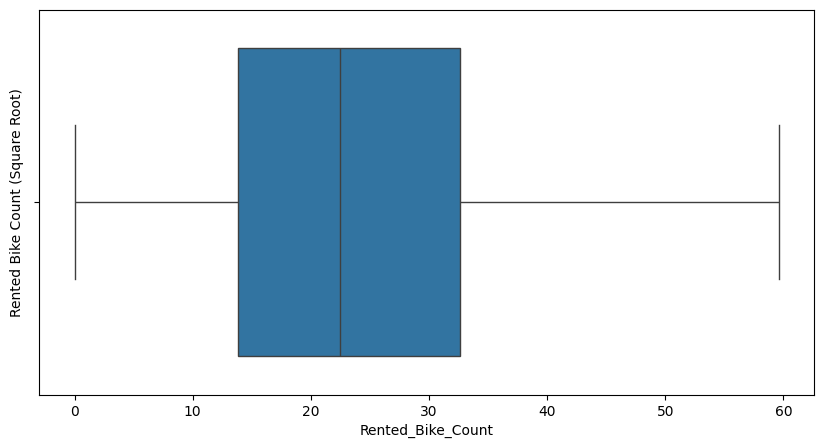

In [216]:
# Check for Outliers again.

plt.figure(figsize=(10, 5))  # Set figure size
plt.ylabel('Rented Bike Count (Square Root)')  # Y-axis label
sns.boxplot(x=np.sqrt(df['Rented_Bike_Count']))  # Create box plot of square root transformed data
plt.show()  # Display the plot

We can see now there is no outliers left in the dataset.

In [217]:
#drop the Dew point temperature column
df=df.drop(['Dew_point_temperature'], axis=1)

In [218]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Rented_Bike_Count  8760 non-null   int64   
 1   Hour               8760 non-null   category
 2   Temperature        8760 non-null   float64 
 3   Humidity           8760 non-null   int64   
 4   Wind_speed         8760 non-null   float64 
 5   Visibility         8760 non-null   int64   
 6   Solar_Radiation    8760 non-null   float64 
 7   Rainfall           8760 non-null   float64 
 8   Snowfall           8760 non-null   float64 
 9   Seasons            8760 non-null   object  
 10  Holiday            8760 non-null   object  
 11  Functioning_Day    8760 non-null   object  
 12  month              8760 non-null   category
 13  weekdays_weekend   8760 non-null   category
dtypes: category(3), float64(5), int64(3), object(3)
memory usage: 779.7+ KB


### 3. Categorical Encoding

***Create Dummy Variables***

***A dataset may contain various type of values,sometimes it contains categorical values.So in order to use these categorical values for programming efficiency we create dummy variables.***

In [219]:
# Encode your categorical columns
# Assign all categorical features to a variable categorical_features
categorical_features = list(df.select_dtypes(['object', 'category']).columns)
categorical_features = pd.Index(categorical_features)
print(categorical_features)

Index(['Hour', 'Seasons', 'Holiday', 'Functioning_Day', 'month',
       'weekdays_weekend'],
      dtype='object')


***One Hot Encoding***

*One hot encoding allows the representation of categorical data to be more expressive. Many machine learning algorithms cannot work with categorical data directly. The categories must be converted into numbers. This is required for both input and output variables that are categorical.*

In [220]:
#Create a copy
df_copy = df

def one_hot_encoding(data, column):
    data = pd.concat([data, pd.get_dummies(data[column], prefix=column, drop_first=True)], axis=1)
    data = data.drop([column], axis=1)
    return data

for col in categorical_features:
    df_copy = one_hot_encoding(df_copy, col)
    df_copy.head()

In [221]:
df_copy.head()

,Rented_Bike_Count,Temperature,Humidity,Wind_speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Hour_1,Hour_2,...,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,weekdays_weekend_1
0,254,-5.2,37,2.2,2000,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
1,204,-5.5,38,0.8,2000,0.0,0.0,0.0,True,False,...,False,False,False,False,False,False,False,False,True,False
2,173,-6.0,39,1.0,2000,0.0,0.0,0.0,False,True,...,False,False,False,False,False,False,False,False,True,False
3,107,-6.2,40,0.9,2000,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False
4,78,-6.0,36,2.3,2000,0.0,0.0,0.0,False,False,...,False,False,False,False,False,False,False,False,True,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

I used one-hot encoding to convert categorical features into numerical representations suitable for machine learning, avoiding the introduction of unintended ordinal relationships between categories.



## ***7. ML Model Implementation***

### ML Model - 1

***Train Test split for regression.***

 Before, fitting any model it is a rule of thumb to split the dataset into a training and test sets. This means some proportions of the data will ge into training the model while some portion will be used to evaluate how our model is performing on an unseen data. The proportions may vary from 60:40, 70:30, 75:25 depending on the person but mostly used le 80:20 for training and testing respectively. In this step we will spllt our dataset into training and testing set using scikit learn library

In [222]:
#Assign the values in x and y.
x=df_copy.drop(columns=['Rented_Bike_Count'], axis=1)
y=np.sqrt(df_copy['Rented_Bike_Count'])
x.head()




,Temperature,Humidity,Wind_speed,Visibility,Solar_Radiation,Rainfall,Snowfall,Hour_1,Hour_2,Hour_3,...,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12,weekdays_weekend_1
0,-5.2,37,2.2,2000,0.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,-5.5,38,0.8,2000,0.0,0.0,0.0,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,-6.0,39,1.0,2000,0.0,0.0,0.0,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3,-6.2,40,0.9,2000,0.0,0.0,0.0,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,-6.0,36,2.3,2000,0.0,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [223]:
y.head()

,Rented_Bike_Count
0,15.937377
1,14.282857
2,13.152946
3,10.344080
4,8.831761


In [224]:
#Create train and test sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=0)
print(x_train.shape)
print(x_test.shape)

(6570, 47)
(2190, 47)


In [225]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 48 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rented_Bike_Count    8760 non-null   int64  
 1   Temperature          8760 non-null   float64
 2   Humidity             8760 non-null   int64  
 3   Wind_speed           8760 non-null   float64
 4   Visibility           8760 non-null   int64  
 5   Solar_Radiation      8760 non-null   float64
 6   Rainfall             8760 non-null   float64
 7   Snowfall             8760 non-null   float64
 8   Hour_1               8760 non-null   bool   
 9   Hour_2               8760 non-null   bool   
 10  Hour_3               8760 non-null   bool   
 11  Hour_4               8760 non-null   bool   
 12  Hour_5               8760 non-null   bool   
 13  Hour_6               8760 non-null   bool   
 14  Hour_7               8760 non-null   bool   
 15  Hour_8               8760 non-null   b

In [226]:
df_copy.describe().columns

Index(['Rented_Bike_Count', 'Temperature', 'Humidity', 'Wind_speed',
       'Visibility', 'Solar_Radiation', 'Rainfall', 'Snowfall'],
      dtype='object')

The mean squared error (MSE) tells you how close a regression line is to a set of points. It does this by taking the distances from the points to the regression line (these distances are the "errors") and squaring them. It's called the mean squared error as you're finding the average of a set of errors. The lower the MSE, the better the forecast.

 MSE formula- (1/n)*∑(actual-forecast)**2*

 Where: n=number of items,

  ∑= summation notation ,
  
   Actual= original or observed y =value,
   
   Forecast=y-value from regression.
   
   Root Mean Square Error (RMSE) is the standard deviation of the residuals (prediction errors).
   
  Mean Absolute Error (MAE) are metrics used to evaluate a Regression Model. Here, errors are the differences between the predicted values (values predicted by our regression model) and the actual values of a variable.

  R-squared (R2) is a statistical measure that represents the proportion of the variance for a dependent variable that's explained by an independent variable or variables in a regression model.
  R² = 1 - (SSR / SST)

Where:

R² is the coefficient of determination (R-squared)
SSR is the sum of squared residuals (unexplained variance)
SST is the total sum of squares (total variance)



  
  Adjusted R-squared is a modified version of R-squared that has been adjusted for the number of predictors in the model.

**LINEAR REGGRESSION**

Regression models describe the relationship between variables by fitting a line to the observed data. Linear regression models use a straight line.

  Linear regression uses a linear approach to model the relationship between independent and dependent variables. In simple words its a best fit line drawn over the values of independent variables and dependent variable. In case of single variable, the formula is same as straight line equation having an intercept and slope.

  y = a + b1x1 + b2x2 + ... + bnxn

Where:

y is the dependent variable


x1, x2, ..., xn are the independent variables


a is the intercept


b1, b2, ..., bn are the coefficients for each independent variable


This equation allows for predicting a dependent variable based on multiple factors.

Gradient descent is the process by which the algorithm tries to update the parameters using a loss function. Loss function is nothing but the diffence between the actual values and predicted values(aka error or residuals). There are different types of loss function but this is the simplest one, Loss function summed over all observation gives the cost functions. The role of gradient descent is to update the parameters till the cost function is minimized i.e., a global minima is reached. It uses a hyperparameter 'alpha' that gives a weightage to the cost function and decides on how big the steps to take. Alpha is called as the learning rate. It is always necesarry to keep an optimal value of alpha as high and low values of alpha might make the gradient descent overshoot or get stuck at a local minima. There are also some basic assumptions that must be fulfilled before implementing this algorithm. They are:

1.No multicollinearity in the dataset.

2.Independent variables should show linear relationship with dv.

3.Residual mean should be 0 or close to O

4.There should be no heteroscedasticity i.e., variance should be constant along the line of best fit.

Let us now implement our first model. We will be using Linear Regression from scikit library.

In [227]:
#Import the packages..
from sklearn.linear_model import LinearRegression
reg=LinearRegression().fit(x_train,y_train)

In [228]:
#Check the score.
reg.score(x_train,y_train)

0.7912528520061131

In [229]:
#Check the coefficient.
reg.coef_

array([ 4.68898841e-01, -1.02730655e-01,  1.83240594e-02,  6.99201660e-04,
        9.18643061e-01, -5.11433364e+00, -2.17367837e-01, -2.18196790e+00,
       -5.03358631e+00, -7.07230151e+00, -9.68767372e+00, -9.28182004e+00,
       -4.17525179e+00,  1.98925527e+00,  7.41924303e+00,  1.62032678e+00,
       -3.02792195e+00, -3.03026157e+00, -1.90797669e+00, -2.28029788e+00,
       -2.40531895e+00, -1.09497292e+00,  7.19633870e-01,  4.50142652e+00,
        1.07240185e+01,  7.21394047e+00,  6.19080711e+00,  6.27641751e+00,
        5.13030977e+00,  1.46617384e+00,  1.92716108e+10,  4.73913235e+10,
        1.78224800e+10,  3.41060568e+00,  2.83867022e+01, -6.19495547e-01,
       -1.44913083e+09, -1.44913082e+09, -1.44913082e+09, -2.95688435e+10,
       -2.95688435e+10, -2.95688435e+10,  1.78224800e+10,  1.78224800e+10,
        1.78224800e+10,  2.04431989e+00, -1.36518483e+00])

In [230]:
# Get the x-train and x-test value.
y_pred_train=reg.predict(x_train)
y_pred_test=reg.predict(x_test)

In [231]:
#Import the packages.
from sklearn.metrics import mean_squared_error

# Calculate MSE
MSE_lr = mean_squared_error(y_train, y_pred_train)
print("MSE:", MSE_lr)

# Calculate RMSE
RMSE_lr = np.sqrt(MSE_lr)
print("RMSE:", RMSE_lr)

# Calculate MAE
MAE_lr = mean_absolute_error(y_train, y_pred_train)
print("MAE:", MAE_lr)

#Import package
from sklearn.metrics import r2_score

# Calculate R-squared
r2_lr = r2_score(y_train, y_pred_train)
print("R2:", r2_lr)

# Calculate Adjusted R-squared
Adjusted_R2_lr = 1 - (1 - r2_score(y_train, y_pred_train)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1))
print("Adjusted R2:", Adjusted_R2_lr)





MSE: 32.14511501689425
RMSE: 5.669666217414766
MAE: 4.301091521806152
R2: 0.7912528520061131
Adjusted R2: 0.7866724990856123


Looks like our train set's r2 score value is 0.79 that means our model is able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [232]:
# Storing the test set matrics value in a dataframe for later comparison.
dict1 ={'Model': 'Linear Regression',
        'MSE':round((MSE_lr),3),
        'RMSE':round((RMSE_lr),3),
        'MAE':round((MAE_lr),3),
        'R2':round((r2_lr),3),
        'Adjusted R2':round((Adjusted_R2_lr),2)}
training_df = pd.DataFrame(dict1, index=[1])

In [233]:
# Import necessary libraries
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate MSE
MSE_lr = mean_squared_error(y_test, y_pred_test)
print("MSE:", MSE_lr)

# Calculate RMSE
RMSE_lr = np.sqrt(MSE_lr)
print("RMSE:", RMSE_lr)

# Calculate MAE
MAE_lr = mean_absolute_error(y_test, y_pred_test)
print("MAE:", MAE_lr)

#Import libraries
from sklearn.metrics import r2_score

# Calculate R-squared and Adjusted R-squared
r2_lr = r2_score(y_test, y_pred_test)
print("R2:", r2_lr)

Adjusted_R2_lr = 1 - (1 - r2_score(y_test, y_pred_test)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1))
print("Adjusted R2:", Adjusted_R2_lr)

MSE: 31.21748092269732
RMSE: 5.587260591980414
MAE: 4.260523053222832
R2: 0.8023789852674572
Adjusted R2: 0.7980427631888254


In [234]:
#Storing the test set metrics value in dataframe for later comparison.

dict2 = {
    "Model": "Linear Regression",
    "MAE": round(MAE_lr, 3),
    "MSE": round(MSE_lr, 3),
    "RMSE": round(RMSE_lr, 3),
    "R2 score": round(r2_lr, 3),
    "Adjusted R2": round(Adjusted_R2_lr, 2)
}

test_df = pd.DataFrame(dict2, index=[1])

***Heteroscedasticity***


Heteroscedasticity refers to a situation where the variance of the errors (residuals) is not constant across all levels of the independent variable(s) in a regression model. This violates one of the assumptions of linear regression, which is that the variance of the errors should be constant (homoscedastic) for all levels of the independent variable(s). If the plot shows a funnel shape, with the spread of residuals increasing or decreasing as the predicted values increase, this is an indication of heteroscedasticity.

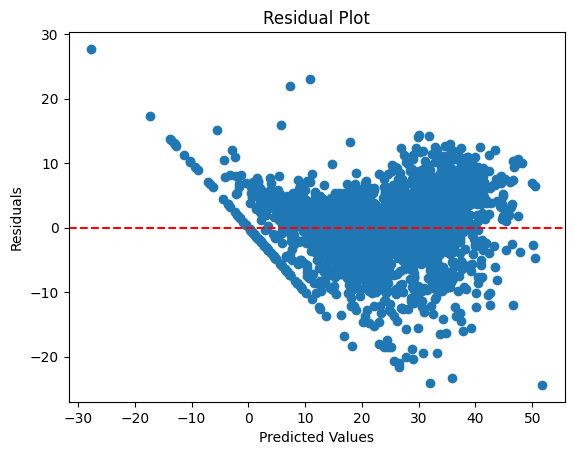

In [235]:
#Heteroscedasticity graph

# Calculate residuals
residuals = y_test - y_pred_test

# Create the residual plot
plt.scatter(y_pred_test, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at y=0
plt.show()

The test set's r2 score is 0.80. This means our linear model is performing well on the data. Let us try to visualize our residuals and see if there is heteroscedasticity(unequal variance or scatter).

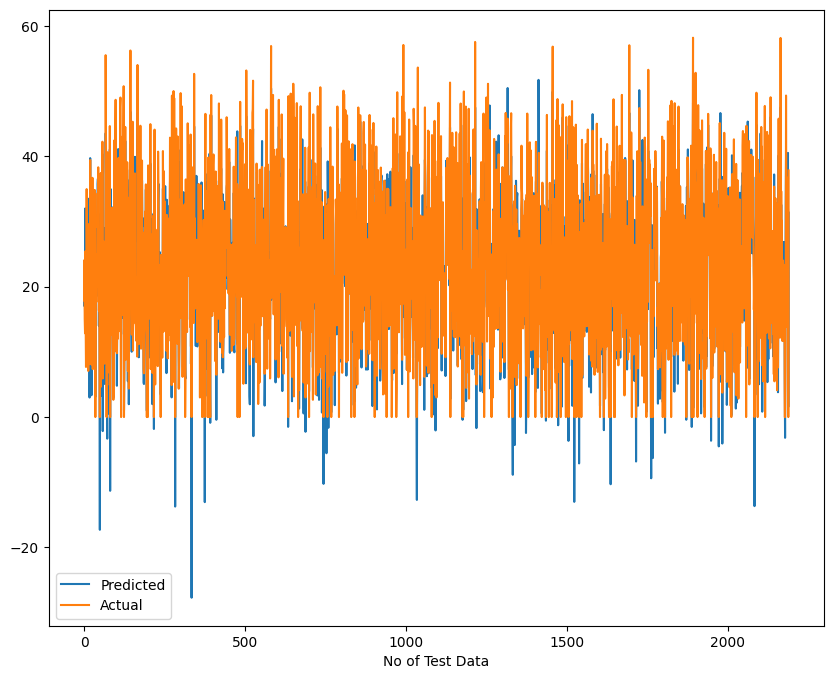

In [236]:

#Actual price vs predicted for Linear Regression plot..
plt.figure(figsize=(10, 8))  # Corrected figsize argument
plt.plot(y_pred_test, label='Predicted')  # Added label for legend
plt.plot(np.array(y_test), label='Actual')  # Added label for legend
plt.legend(['Predicted','Actual'])  # Display legend
plt.xlabel('No of Test Data')
plt.show()

***Ridge and Lasso Regression***

Ridge and Lasso Regression are types of Regularization techniques.

Regularization techniques are used to deal with overfitting and when the dataset is large.

Ridge and Lasso Regression involve adding penalties to the regression function

***Lasso Regression***

 Lasso regression analysis is a shrinkage and variable selection method for linear regression models. The goal of Lasso Regression is to obtain the subset of predictors that minimizes prediction error for a quantitative response variable. It uses the Linear regression model with L.1 regularization.

In [237]:
#Import libraries.
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [238]:
#Create an instance of Lasso Regression implementation.
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0,max_iter=3000)

#Fit the Lasso model
lasso.fit(x_train,y_train)

#Create the model score
print(lasso.score(x_test,y_test),lasso.score(x_train,y_train))

0.38086483341841226 0.3983632039954085


In [239]:
#Get the x-train,x-test value.
y_pred_train_lasso=lasso.predict(x_train)
y_pred_test_lasso=lasso.predict(x_test)

In [240]:
from sklearn.metrics import mean_squared_error

# Calculate MSE
MSE_lasso = mean_squared_error(y_train, y_pred_train_lasso)
print("MSE:", MSE_lasso)

#Calculate RMSE
RMSE_lasso = np.sqrt(MSE_lasso)
print("RMSE:", RMSE_lasso)

#Calculate MAE
MAE_lasso = mean_absolute_error(y_train, y_pred_train_lasso)
print("MAE:", MAE_lasso)

from sklearn.metrics import r2_score
#Calculate r2 and adjusted r2_score.
r2_lasso = r2_score(y_train, y_pred_train_lasso)
print("R2:", r2_lasso)
Adjusted_R2_lasso = (1 - (1 - r2_score(y_train, y_pred_train_lasso)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_lasso)



MSE: 92.6464586070881
RMSE: 9.625303039753508
MAE: 7.304643598875601
R2: 0.3983632039954085
Adjusted R2: 0.38516202313069525


Looks like train set's r2 score value is 0.39 that means our model is not able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [241]:
#Storing the test set metrics in dataframe for later comparison.
dict1={'Model': 'Lasso Regression',
        'MSE':round((MSE_lasso),3),
        'RMSE':round((RMSE_lasso),3),
        'MAE':round((MAE_lasso),3),
        'R2':round((r2_lasso),3),
        'Adjusted R2':round((Adjusted_R2_lasso),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [242]:
from sklearn.metrics import mean_squared_error

# Calculate MSE
MSE_lasso = mean_squared_error(y_test, y_pred_test_lasso)
print("MSE:", MSE_lasso)

# Calculate RMSE
RMSE_lasso = np.sqrt(MSE_lasso)
print("RMSE:", RMSE_lasso)

# Calculate MAE
MAE_lasso = mean_absolute_error(y_test, y_pred_test_lasso)
print("MAE:", MAE_lasso)

# Calculate R2 and Adjusted R2
r2_lasso = r2_score(y_test, y_pred_test_lasso)
print("R2:", r2_lasso)
Adjusted_R2_lasso = (1 - (1 - r2_score(y_test, y_pred_test_lasso)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_lasso)

MSE: 97.80255544932679
RMSE: 9.8895174528046
MAE: 7.505550890266117
R2: 0.38086483341841226
Adjusted R2: 0.3672797013785736


The test set's r2_score is 0.38. This means our linear model is not performing well on the data.


In [243]:
#Storing the test set metrics in dataframe for later coparison.
dict2 = {
    "Model": "Lasso Regression",
    "MAE": round(MAE_lasso, 3),
    "MSE": round(MSE_lasso, 3),
    "RMSE": round(RMSE_lasso, 3),
    "R2 score": round(r2_lasso, 3),
    "Adjusted R2": round(Adjusted_R2_lasso, 2)
}

test_df = pd.concat([test_df, pd.DataFrame([dict2])], ignore_index=True)  # Concatenate the new row to the existing DataFrame

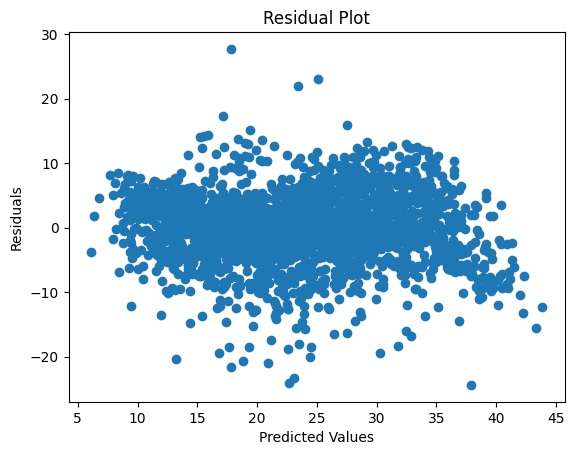

In [244]:
#Heteroscadacity residual plot.
plt.scatter(y_pred_test_lasso, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

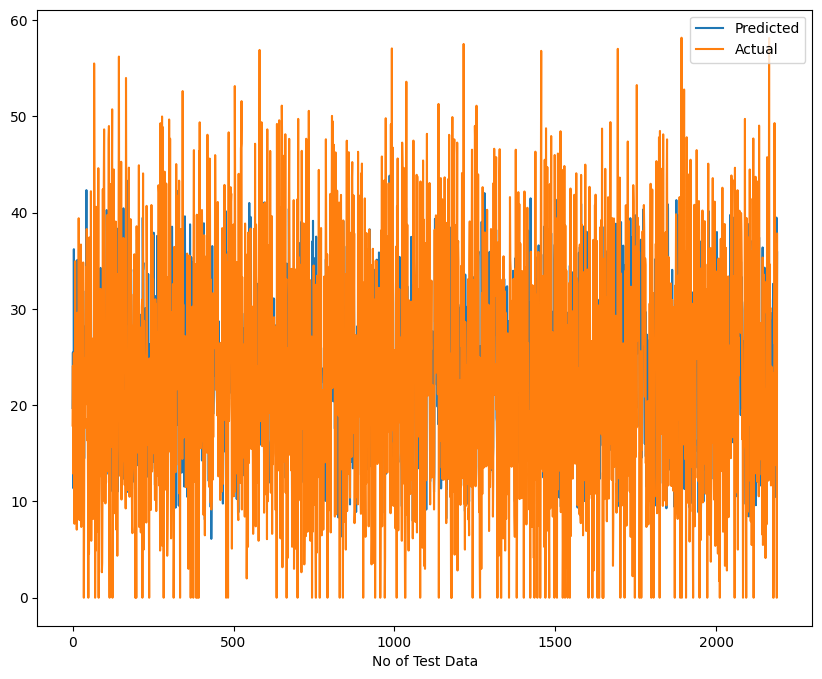

In [245]:
#Plot figure.
plt.figure(figsize=(10, 8))
plt.plot(y_pred_test_lasso, label='Predicted')
plt.plot(np.array(y_test), label='Actual')
plt.legend(['Predicted','Actual'])
plt.xlabel('No of Test Data')
plt.show()


***RIDGE REGRESSION***

Ridge regression is a method of estimating the coefficients of regression models in scenarios where the independent variables are highly correlated. It uses the linear regression model with the L2 regularization method.

In [246]:
#Import the packages.
from sklearn.linear_model import Ridge


ridge = Ridge(alpha=0.1)

In [247]:
#Fit the model.
ridge.fit(x_train,y_train)

Ridge(alpha=0.1)

In [248]:
#Check the score..
ridge.score(x_train,y_train)

0.7912527761772726

In [249]:
# Get the x_train and x_test values
y_pred_train_ridge=ridge.predict(x_train)
y_pred_test_ridge=ridge.predict(x_test)

In [250]:

y_pred_train_ridge


array([20.62298584, 30.79728204, 19.9313908 , ..., 34.40392233,
       23.28141619, 22.22957588])

In [251]:
y_pred_test_ridge

array([17.10269158, 23.09797634, 20.39407758, ..., 40.50590122,
        1.57892994, 31.35388445])

In [252]:
#Import the packages
from sklearn.metrics import mean_squared_error

# Calculate MSE
MSE_ridge = mean_squared_error(y_train, y_pred_train_ridge)
print("MSE:", MSE_ridge)

#Calculate RMSE
RMSE_ridge = np.sqrt(MSE_ridge)
print("RMSE:", RMSE_ridge)

#Calculate MAE
MAE_ridge = mean_absolute_error(y_train, y_pred_train_ridge)
print("MAE:", MAE_ridge)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_ridge = r2_score(y_train, y_pred_train_ridge)
print("R2:", r2_ridge)

Adjusted_R2_ridge = (1 - (1 - r2_score(y_train, y_pred_train_ridge)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_ridge)

MSE: 32.145126693828864
RMSE: 5.6696672471873395
MAE: 4.301221643579305
R2: 0.7912527761772726
Adjusted R2: 0.786672421592927


Looks like our train set's r2 score value is 0.79 that means our model is able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [253]:
#Storing the test set metrices in a dataframe for later comparison.
dict1={'Model': 'Ridge Regression',
        'MSE':round((MSE_ridge),3),
        'RMSE':round((RMSE_ridge),3),
        'MAE':round((MAE_ridge),3),
        'R2':round((r2_ridge),3),
        'Adjusted R2':round((Adjusted_R2_ridge),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [254]:
#Import the packages.
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_ridge = mean_squared_error(y_test, y_pred_test_ridge)
print("MSE:", MSE_ridge)

#Calculate RMSE
RMSE_ridge = np.sqrt(MSE_ridge)
print("RMSE:", RMSE_ridge)

#Calculate MAE
MAE_ridge = mean_absolute_error(y_test, y_pred_test_ridge)
print("MAE:", MAE_ridge)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_ridge = r2_score(y_test, y_pred_test_ridge)
print("R2:", r2_ridge)
Adjusted_R2_ridge = (1- (1 - r2_score(y_test, y_pred_test_ridge)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] -1)))
print("Adjusted R2:", Adjusted_R2_ridge)

MSE: 31.218732967563575
RMSE: 5.587372635466832
MAE: 4.260759424869219
R2: 0.8023710592474951
Adjusted R2: 0.79803466325526


The R2 score for the test set is 0.80. This means our linear model is performing well on the data. Let us try to visualize our residuals and see if there is heteroscedasticity(unequal variance or scatter).

In [255]:
#Storing the test set metrics value in dataframe for later comparison.
dict2 = {
    "Model": "Ridge Regression",
    "MAE": round(MAE_ridge, 3),
    "MSE": round(MSE_ridge, 3),
    "RMSE": round(RMSE_ridge, 3),
    "R2 score": round(r2_ridge, 3),
    "Adjusted R2": round(Adjusted_R2_ridge, 2)
}
test_df = pd.concat([test_df, pd.DataFrame([dict2])], ignore_index=True)

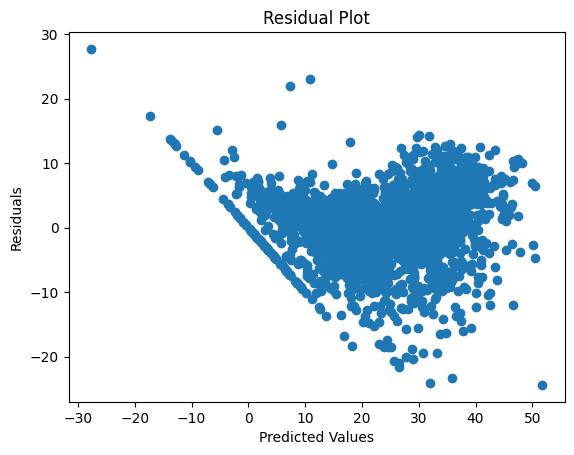

In [256]:
#Heteroscadacity-residual plot
plt.scatter(y_pred_test_ridge, residuals)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

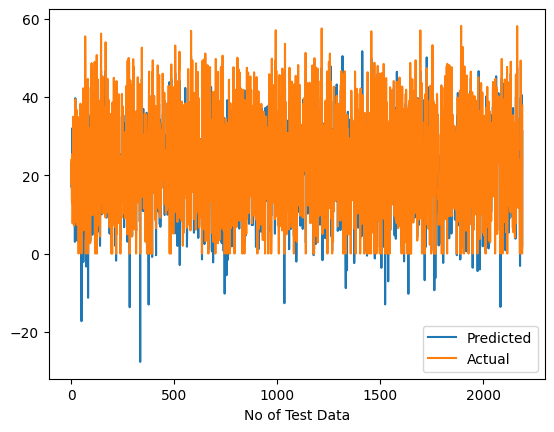

In [257]:
#Plot the figure.
plt.figure
plt.plot(y_pred_test_ridge, label='Predicted')
plt.plot(np.array(y_test), label='Actual')
plt.legend(['Predicted','Actual'])
plt.xlabel('No of Test Data')
plt.show()

***ELASTIC NET REGGRESSION***

Elastic Net regression is a linear regression model that combines both L1 (Lasso) and L2 (Ridge) regularization penalties to overcome some of the limitations of each individual method.

 The model introduces two hyperparameters, alpha and L1 ratio, which control the strength of the L1 and L2 penalties, respectively.

 Elastic Net regression is particularly useful when dealing with datasets that have high dimensionality and multicollinearity between features.

In [258]:
#Import the packages
from sklearn.linear_model import ElasticNet
#a* L1 + b*L2
#alpha = a+b and l1_ratio = a/(a+b)
elasticnet=ElasticNet(alpha=0.1,l1_ratio=0.5)

In [259]:
#Fit the model
elasticnet.fit(x_train,y_train)

ElasticNet(alpha=0.1)

In [260]:
#check score
elasticnet.score(x_train,y_train)

0.641910450609957

In [261]:
#Get the x_train and x_test values.
y_pred_train_elasticnet=elasticnet.predict(x_train)
y_pred_test_elasticnet=elasticnet.predict(x_test)

In [262]:
print(y_pred_train_elasticnet)
print(y_pred_test_elasticnet)

[15.68077567 31.24309653 17.3320067  ... 32.50762556 22.63580595
 19.21383635]
[19.01670529 24.63235562 18.23867345 ... 39.95161758 18.30435149
 32.95386409]


In [263]:
#Import the packages
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_elasticnet = mean_squared_error(y_train, y_pred_train_elasticnet)
print("MSE:", MSE_elasticnet)

#calculate RMSE
RMSE_elasticnet = np.sqrt(MSE_elasticnet)
print("RMSE:", RMSE_elasticnet)

#Calculate MAE
MAE_elasticnet = mean_absolute_error(y_train, y_pred_train_elasticnet)
print("MAE:", MAE_elasticnet)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_elasticnet = r2_score(y_train, y_pred_train_elasticnet)
print("R2:", r2_elasticnet)
Adjusted_R2_elasticnet = (1 - (1 - r2_score(y_train, y_pred_train_elasticnet)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] -1)))
print("Adjusted R2:", Adjusted_R2_elasticnet)

MSE: 55.14245278133264
RMSE: 7.425796440876402
MAE: 5.653172410366239
R2: 0.641910450609957
Adjusted R2: 0.6340532102638636


It seems our train set's r2 score value is 0.64 that means our model is able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [264]:
#Storing the test set metrics in a dataframe for later comparison.
dict1={'Model': 'ElasticNet Regression',
        'MSE':round((MSE_elasticnet),3),
        'RMSE':round((RMSE_elasticnet),3),
        'MAE':round((MAE_elasticnet),3),
        'R2':round((r2_elasticnet),3),
        'Adjusted R2':round((Adjusted_R2_elasticnet),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [265]:
#Import packages.
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_elasticnet = mean_squared_error(y_test, y_pred_test_elasticnet)
print("MSE:", MSE_elasticnet)

#Calculate RMSE
RMSE_elasticnet = np.sqrt(MSE_elasticnet)
print("RMSE:", RMSE_elasticnet)

#Calculate MAE
MAE_elasticnet = mean_absolute_error(y_test, y_pred_test_elasticnet)
print("MAE:", MAE_elasticnet)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_elasticnet = r2_score(y_test, y_pred_test_elasticnet)
print("R2:", r2_elasticnet)
Adjusted_R2_elasticnet = (1 - (1 - r2_score(y_test, y_pred_test_elasticnet)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] -1)))
print("Adjusted R2:", Adjusted_R2_elasticnet)



MSE: 57.773040965512614
RMSE: 7.600857909835745
MAE: 5.765579824382158
R2: 0.6342700742554702
Adjusted R2: 0.6262451879296098


The r2 score for the test set is 0.63. This means our linear model is performing well on the data. Let us try to visualize our residuals and see if there is heteroscedasticity(unequal variance or scatter).

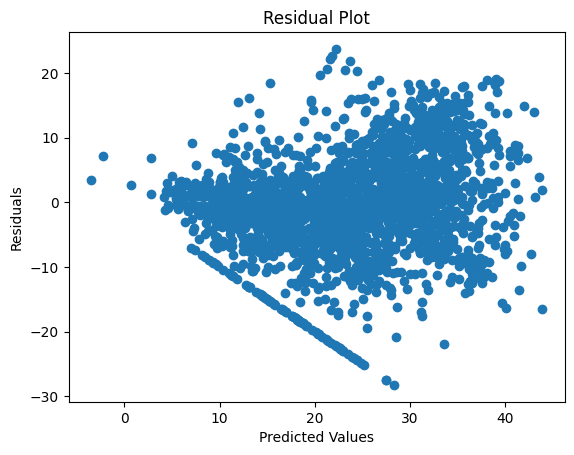

In [266]:
#Hetroscadicity-residual plot.
plt.scatter((y_pred_test_elasticnet),(y_test)-(y_pred_test_elasticnet))
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

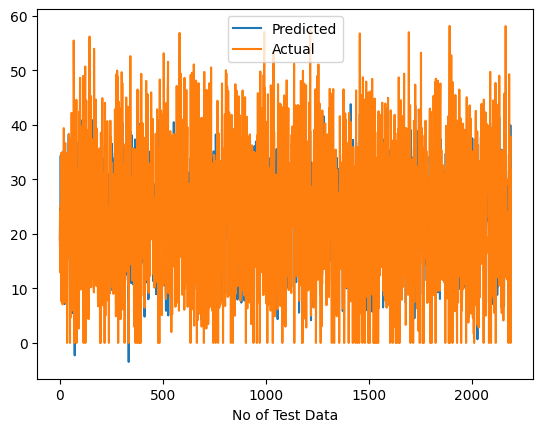

In [267]:
#figure plot.
plt.figure
plt.plot(y_pred_test_elasticnet, label='Predicted')
plt.plot(np.array(y_test), label='Actual')
plt.legend(['Predicted','Actual'])
plt.xlabel('No of Test Data')
plt.show()

**DECISION TREE**

A decision tree is a type of supervised machine leaming algorithm that is commonly used for classification and regression tasks. It works by recursively splitting the data into subsets based on the values of certain attributes, ultimately arriving at a set of decision rules that can be used to classify or predict outcomes for new data

In [268]:
#Import packages
from sklearn.tree import DecisionTreeRegressor

decision_regressor = DecisionTreeRegressor(criterion='friedman_mse',max_depth=8,max_features=9,max_leaf_nodes=100,)
decision_regressor.fit(x_train,y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=8, max_features=9,
                      max_leaf_nodes=100)

In [269]:
#Get x_train and x_test value.
y_pred_train_decision = decision_regressor.predict(x_train)
y_pred_test_decision = decision_regressor.predict(x_test)

In [270]:
print(y_pred_train_decision)
print(y_pred_test_decision)

[19.0617018  33.43062481 12.62433676 ... 40.37920972 24.67878244
 19.47503643]
[24.67878244 19.0617018  16.06487561 ... 40.37920972 24.67878244
 33.43062481]


In [271]:
#Import the packages.
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_decision = mean_squared_error(y_train, y_pred_train_decision)
print("MSE:", MSE_decision)

#Calculate RMSE
RMSE_decision = np.sqrt(MSE_decision)
print("RMSE:", RMSE_decision)

#Calculate MAE
MAE_decision = mean_absolute_error(y_train, y_pred_train_decision)
print("MAE:", MAE_decision)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_decision = r2_score(y_train, y_pred_train_decision)
print("R2:", r2_decision)
Adjusted_R2_decision = (1 - (1 - r2_score(y_train, y_pred_train_decision)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_decision)

MSE: 69.77022860292041
RMSE: 8.352857511230537
MAE: 6.061484095014474
R2: 0.5469191437614491
Adjusted R2: 0.5369775936945902


As we can see the r2 score of oue model is 0.52 which means the prediction is not very accurate.

In [272]:
#Storing the test set in a dataframe for later comparison.
dict1={'Model': 'Decision Tree Regression',
        'MSE':round((MSE_decision),3),
        'RMSE':round((RMSE_decision),3),
        'MAE':round((MAE_decision),3),
        'R2':round((r2_decision),3),
        'Adjusted R2':round((Adjusted_R2_decision),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [273]:
#Import packages
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_decision = mean_squared_error(y_test, y_pred_test_decision) # Call the function with the data

#Calculate RMSE
RMSE_decision = np.sqrt(MSE_decision)
print("RMSE:", RMSE_decision)

#calculate MAE
MAE_decision = mean_absolute_error(y_test, y_pred_test_decision)
print("MAE:", MAE_decision)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_decision = r2_score(y_test, y_pred_test_decision)
print("R2:", r2_decision)
Adjusted_R2_decision = (1 - (1 - r2_score(y_test, y_pred_test_decision)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_decision)

RMSE: 9.101940973814695
MAE: 6.562271246377734
R2: 0.4755509542757018
Adjusted R2: 0.4640434355319848


We can see the R2 score of our model is 0.44,which is not very good score.It means the model is not performing well..

In [274]:
#Storing test set metrics to a dataframe for later comparison
dict2 = {
    "Model": "Decision Tree Regression",
    "MAE": round(MAE_decision, 3),
    "MSE": round(MSE_decision, 3),
    "RMSE": round(RMSE_decision, 3),
    "R2 score": round(r2_decision, 3),
    "Adjusted R2": round(Adjusted_R2_decision, 2)
}

test_df = pd.concat([test_df, pd.DataFrame([dict2])], ignore_index=True)

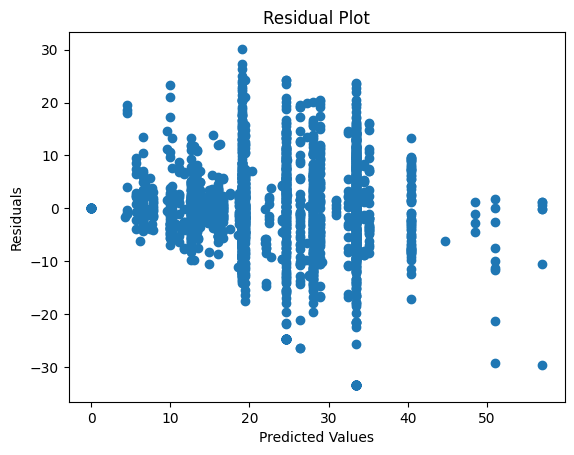

In [275]:
#Hetroscadicity-residual plot
plt.scatter((y_pred_test_decision),(y_test)-(y_pred_test_decision))
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

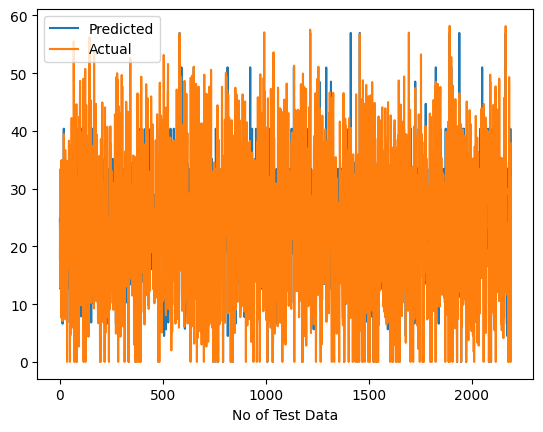

In [276]:
#figure plot
plt.figure
plt.plot(y_pred_test_decision, label='Predicted')
plt.plot(np.array(y_test), label='Actual')
plt.legend(['Predicted','Actual'])
plt.xlabel('No of Test Data')
plt.show()

**RANDOM FOREST**

In [277]:
#Import packages
from sklearn.ensemble import RandomForestRegressor

#Create an instance of RF regressor
rf_model = RandomForestRegressor()

#Fit the model
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [278]:
#Making predictions on tain test data
y_pred_train_rf = rf_model.predict(x_train)
y_pred_test_rf = rf_model.predict(x_test)

In [279]:
#Import packages
from sklearn.metrics import mean_squared_error
print("Model score:", rf_model.score(x_train,y_train))

#Calculate MSE
MSE_rf = mean_squared_error(y_train, y_pred_train_rf)
print("MSE:", MSE_rf)

#Calculate RMSE
RMSE_rf = np.sqrt(MSE_rf)
print("RMSE:", RMSE_rf)

#Calculate MAE
MAE_rf = mean_absolute_error(y_train, y_pred_train_rf)
print("MAE:", MAE_rf)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_rf = r2_score(y_train, y_pred_train_rf)
print("R2:", r2_rf)
Adjusted_R2_rf = (1 - (1 - r2_score(y_train, y_pred_train_rf)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:",Adjusted_R2_rf)



Model score: 0.9897572824571426
MSE: 1.5772830271690887
RMSE: 1.255899290217607
MAE: 0.7957681020169816
R2: 0.9897572824571426
Adjusted R2: 0.9895325356203012


Looks like our train set's r2 score value is 0.98 that means our model is able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [280]:
#Storing test set metrics in dataframe for later comparison
dict1={'Model': 'Random Forest Regression',
        'MSE':round((MSE_rf),3),
        'RMSE':round((RMSE_rf),3),
        'MAE':round((MAE_rf),3),
        'R2':round((r2_rf),3),
        'Adjusted R2':round((Adjusted_R2_rf),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [281]:
#Import packages
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_rf = mean_squared_error(y_test, y_pred_test_rf)
print("MSE:", MSE_rf)

#Calculate RMSE
RMSE_rf = np.sqrt(MSE_rf)
print("RMSE:", RMSE_rf)

#Calculate MAE
MAE_rf = mean_absolute_error(y_test, y_pred_test_rf)
print("MAE:", MAE_rf)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_rf = r2_score(y_test, y_pred_test_rf)
print("R2:", r2_rf)
Adjusted_R2_rf = (1- (1 - r2_score(y_test, y_pred_test_rf)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] -1)))
print("Adjusted R2:", Adjusted_R2_rf)

MSE: 12.641981027454964
RMSE: 3.5555563597635413
MAE: 2.1973471573551064
R2: 0.9199704446024424
Adjusted R2: 0.9182144272804604


The r2 score for the test set is 0.91. This means our linear model is performing well on the data. Let us try to visualize our residuals and see if there is heteroscedasticity(unequal variance or scatter).

In [282]:
#Storing the test metrics in dataframe
dict2 = {
    "Model": "Random Forest Regression",
    "MAE": round(MAE_rf, 3),
    "MSE": round(MSE_rf, 3),
    "RMSE": round(RMSE_rf, 3),
    "R2 score": round(r2_rf, 3),
    "Adjusted R2": round(Adjusted_R2_rf, 2)
}
test_df = pd.concat([test_df, pd.DataFrame([dict2])], ignore_index=True)

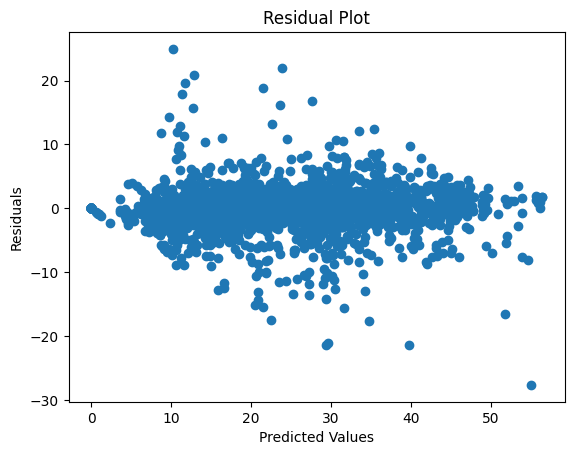

In [283]:
#Heteroscadicity-residual plot.
plt.scatter((y_pred_test_rf),(y_test)-(y_pred_test_rf))
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()


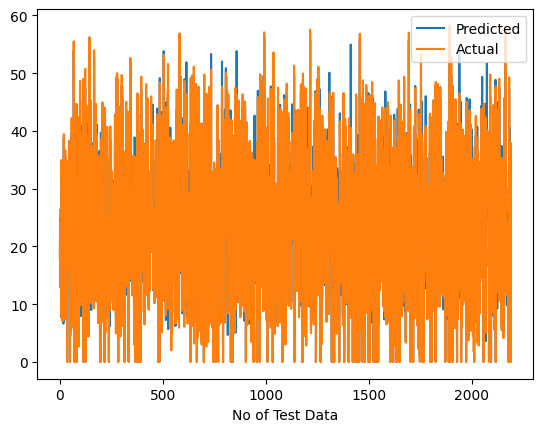

In [284]:
#Figure plot
plt.figure
plt.plot(y_pred_test_rf, label='Predicted')
plt.plot(np.array(y_test), label='Actual')
plt.legend(['Predicted','Actual'])
plt.xlabel('No of Test Data')
plt.show()

In [285]:
rf_model.feature_importances_

array([3.13621599e-01, 1.55515857e-01, 1.17071344e-02, 1.20942996e-02,
       3.14885396e-02, 3.39040069e-02, 1.25119210e-03, 4.86849643e-03,
       1.29422040e-02, 2.05196291e-02, 3.03050267e-02, 2.55981207e-02,
       8.38617032e-03, 3.96411096e-03, 1.31766609e-02, 1.06980299e-03,
       2.28419822e-03, 1.13181208e-03, 3.28417310e-04, 2.96264138e-04,
       4.18981857e-04, 1.50022784e-03, 3.75798580e-03, 1.07680182e-02,
       3.14736052e-02, 1.75832638e-02, 1.21329488e-02, 1.22989037e-02,
       9.89512600e-03, 3.74412371e-03, 4.02276913e-03, 9.31867172e-04,
       1.20872425e-02, 3.86631954e-03, 1.49872334e-01, 2.92738627e-04,
       4.34012067e-03, 1.29951792e-03, 1.57383865e-03, 2.63983243e-03,
       5.94358006e-04, 2.06215418e-03, 7.90886872e-04, 2.59496665e-03,
       4.54130725e-03, 7.47023856e-04, 1.97159954e-02])

In [286]:
importances = rf_model.feature_importances_
importance_dict = {
    'Feature': list(x_train.columns),
    'Feature Importance': importances
}
importance_df = pd.DataFrame(importance_dict)

In [287]:
importance_df['Feature Importance']=round(importance_df['Feature Importance'],2)

In [288]:
importance_df.sort_values(by='Feature Importance',ascending=False)

,Feature,Feature Importance
0,Temperature,0.31
1,Humidity,0.16
34,Functioning_Day_Yes,0.15
10,Hour_4,0.03
4,Solar_Radiation,0.03
5,Rainfall,0.03
24,Hour_18,0.03
11,Hour_5,0.03
25,Hour_19,0.02
46,weekdays_weekend_1,0.02


In [289]:
#Fit the model
rf_model.fit(x_train,y_train)

RandomForestRegressor()

In [290]:
features=x_train.columns
importances=rf_model.feature_importances_
indices=np.argsort(importances)

([<matplotlib.axis.YTick at 0x7df5fceb87f0>,
 [Text(0, 0, 'month_2'),
  Text(0, 1, 'Hour_15'),
  Text(0, 2, 'Hour_14'),
  Text(0, 3, 'Hour_13'),
  Text(0, 4, 'Hour_9'),
  Text(0, 5, 'month_9'),
  Text(0, 6, 'Hour_12'),
  Text(0, 7, 'Seasons_Summer'),
  Text(0, 8, 'month_4'),
  Text(0, 9, 'Snowfall'),
  Text(0, 10, 'Hour_1'),
  Text(0, 11, 'month_5'),
  Text(0, 12, 'month_12'),
  Text(0, 13, 'month_7'),
  Text(0, 14, 'Hour_16'),
  Text(0, 15, 'month_3'),
  Text(0, 16, 'Hour_23'),
  Text(0, 17, 'Hour_11'),
  Text(0, 18, 'Seasons_Spring'),
  Text(0, 19, 'Wind_speed'),
  Text(0, 20, 'Hour_10'),
  Text(0, 21, 'Holiday_No Holiday'),
  Text(0, 22, 'Visibility'),
  Text(0, 23, 'month_6'),
  Text(0, 24, 'Hour_7'),
  Text(0, 25, 'month_8'),
  Text(0, 26, 'month_11'),
  Text(0, 27, 'Hour_6'),
  Text(0, 28, 'Hour_2'),
  Text(0, 29, 'month_10'),
  Text(0, 30, 'Hour_17'),
  Text(0, 31, 'Hour_22'),
  Text(0, 32, 'Hour_8'),
  Text(0, 33, 'Hour_20'),
  Text(0, 34, 'Hour_21'),
  Text(0, 35, 'Hour_3'),
 

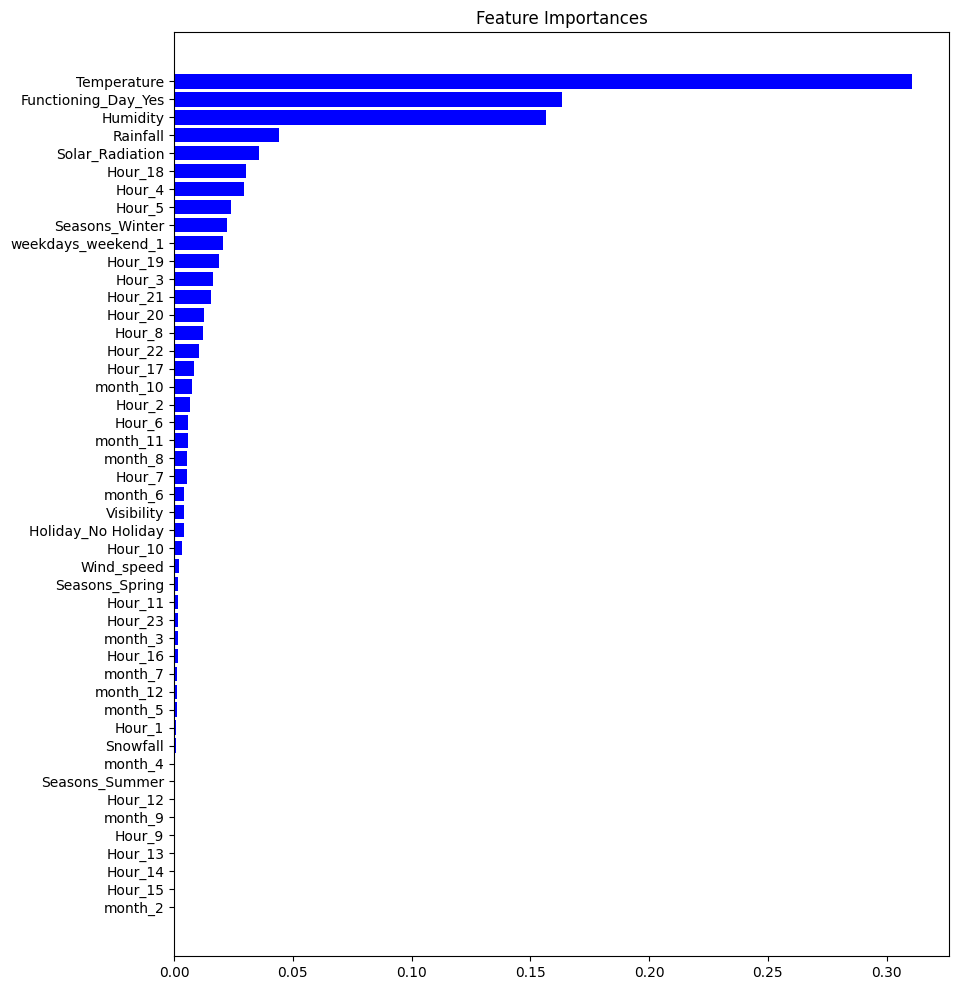

In [340]:
#Plot the figure
plt.figure(figsize=(10,12))
plt.title('Feature Importances')
plt.barh(range(len(indices)),importances[indices],color='b',align='center')
plt.yticks(range(len(indices)),[features[i] for i in indices])

***GRADIENT BOOSTING***

In [292]:
#Import packages
from sklearn.ensemble import GradientBoostingRegressor

#Create an instance of Gradient Boosting regressor
gb_model = GradientBoostingRegressor()

#Fit the model
gb_model.fit(x_train,y_train)

GradientBoostingRegressor()

In [293]:
#Making prediction on train and test data
y_pred_train_gb = gb_model.predict(x_train)
y_pred_test_gb = gb_model.predict(x_test)

In [294]:
#Import packages
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_gb = mean_squared_error(y_train, y_pred_train_gb)
print("MSE:", MSE_gb)

#Calculate RMSE
RMSE_gb = np.sqrt(MSE_gb)
print("RMSE:", RMSE_gb)

#Calculate MAE
MAE_gb = mean_absolute_error(y_train, y_pred_train_gb)
print("MAE:", MAE_gb)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_gb = r2_score(y_train, y_pred_train_gb)
print("R2:", r2_gb)
Adjusted_R2_gb = (1 - (1 - r2_score(y_train, y_pred_train_gb)) * ((x_test.shape[0] - 1) / (x_test.shape[0] -x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_gb)


MSE: 19.09343061021
RMSE: 4.369603026615804
MAE: 3.3013097059201097
R2: 0.8760091795221207
Adjusted R2: 0.8732885592782083


 A we can see our train set's R2 score value is 0.87 that means our model is able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [295]:
#Storing the test set metrics in dataframe.
dict1={'Model': 'Gradient Boosting Regression',
        'MSE':round((MSE_gb),3),
        'RMSE':round((RMSE_gb),3),
        'MAE':round((MAE_gb),3),
        'R2':round((r2_gb),3),
        'Adjusted R2':round((Adjusted_R2_gb),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [296]:
#Import the packages.
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_gb = mean_squared_error (y_test, y_pred_test_gb)
print("MSE:", MSE_gb)

#Calculate RMSE
RMSE_gb = np.sqrt(MSE_gb)
print("RMSE:", RMSE_gb)

#Calculate MAE
MAE_gb = mean_absolute_error(y_test, y_pred_test_gb)
print("MAE:", MAE_gb)

#Import packages
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_gb = r2_score(y_test, y_pred_test_gb)
print("R2:", r2_gb)
Adjusted_R2_gb = (1 - (1 - r2_score(y_test, y_pred_test_gb)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_gb)

MSE: 21.519381971053217
RMSE: 4.638898788619258
MAE: 3.496871316542865
R2: 0.8637724128968804
Adjusted R2: 0.8607832921714619


The r2 score for the test set is 0.86. This means our linear model is performing well on the data. Let us try to visualize our residuals and see if there is heteroscedasticity(unequal variance or scatter).

In [297]:
#Storing the y_test set metrics in dataframe..
dict2 = {
    "Model": "Gradient Boosting Regression",
    "MAE": round(MAE_gb, 3),
    "MSE": round(MSE_gb, 3),
    "RMSE": round(RMSE_gb, 3),
    "R2 score": round(r2_gb, 3),
    "Adjusted R2": round(Adjusted_R2_gb, 2)
}
test_df = pd.concat([test_df, pd.DataFrame([dict2])], ignore_index=True)

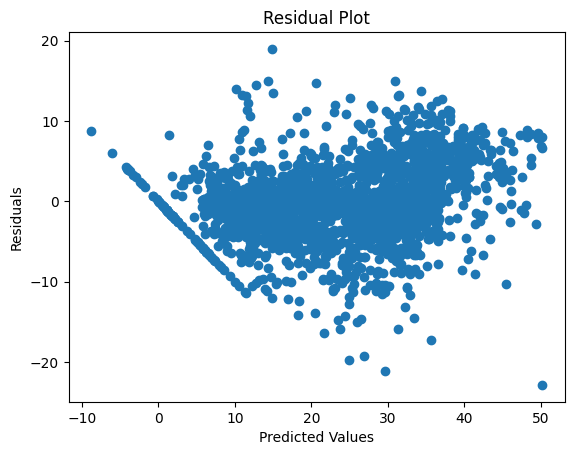

In [298]:
#Heteroscadasticity-residual plot
plt.scatter((y_pred_test_gb),(y_test)-(y_pred_test_gb))
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [299]:
gb_model.feature_importances_

array([3.22530099e-01, 1.29059178e-01, 2.36316095e-04, 5.02544021e-04,
       4.89603250e-02, 6.53942926e-02, 9.41346905e-06, 3.54528297e-04,
       5.55116789e-03, 1.47540181e-02, 2.71652952e-02, 2.07853876e-02,
       5.53615753e-03, 4.21330488e-05, 1.03746894e-02, 0.00000000e+00,
       3.12010802e-03, 1.49189245e-03, 0.00000000e+00, 0.00000000e+00,
       4.65071042e-05, 0.00000000e+00, 1.92297365e-04, 7.41868419e-03,
       2.99824877e-02, 1.76286106e-02, 1.26241734e-02, 1.52003098e-02,
       1.26692962e-02, 3.78557652e-04, 2.35772283e-04, 4.18768111e-05,
       3.26950228e-02, 1.96041409e-03, 1.75602474e-01, 0.00000000e+00,
       1.48757418e-03, 1.02006460e-04, 5.02728704e-04, 4.28464592e-03,
       0.00000000e+00, 3.02668261e-03, 0.00000000e+00, 6.41893200e-03,
       4.85755587e-03, 7.62177268e-04, 1.60136680e-02])

**FEATURES STORED**

In [300]:
importances = gb_model.feature_importances_
importance_dict = {
    'Feature': list(x_train.columns),
    'Feature Importance': importances
}
importance_df = pd.DataFrame(importance_dict)

In [301]:
importance_df['Feature Importance']=round(importance_df['Feature Importance'],2)

In [302]:
importance_df.head()

,Feature,Feature Importance
0,Temperature,0.32
1,Humidity,0.13
2,Wind_speed,0.00
3,Visibility,0.00
4,Solar_Radiation,0.05


In [303]:
importance_df.sort_values(by='Feature Importance',ascending=False)

,Feature,Feature Importance
0,Temperature,0.32
34,Functioning_Day_Yes,0.18
1,Humidity,0.13
5,Rainfall,0.07
4,Solar_Radiation,0.05
32,Seasons_Winter,0.03
24,Hour_18,0.03
10,Hour_4,0.03
11,Hour_5,0.02
27,Hour_21,0.02


In [304]:
gb_model.fit(x_train,y_train)

GradientBoostingRegressor()

In [305]:
features = x_train.columns
importances = gb_model.feature_importances_
indices = np.argsort(importances)

<BarContainer object of 47 artists>

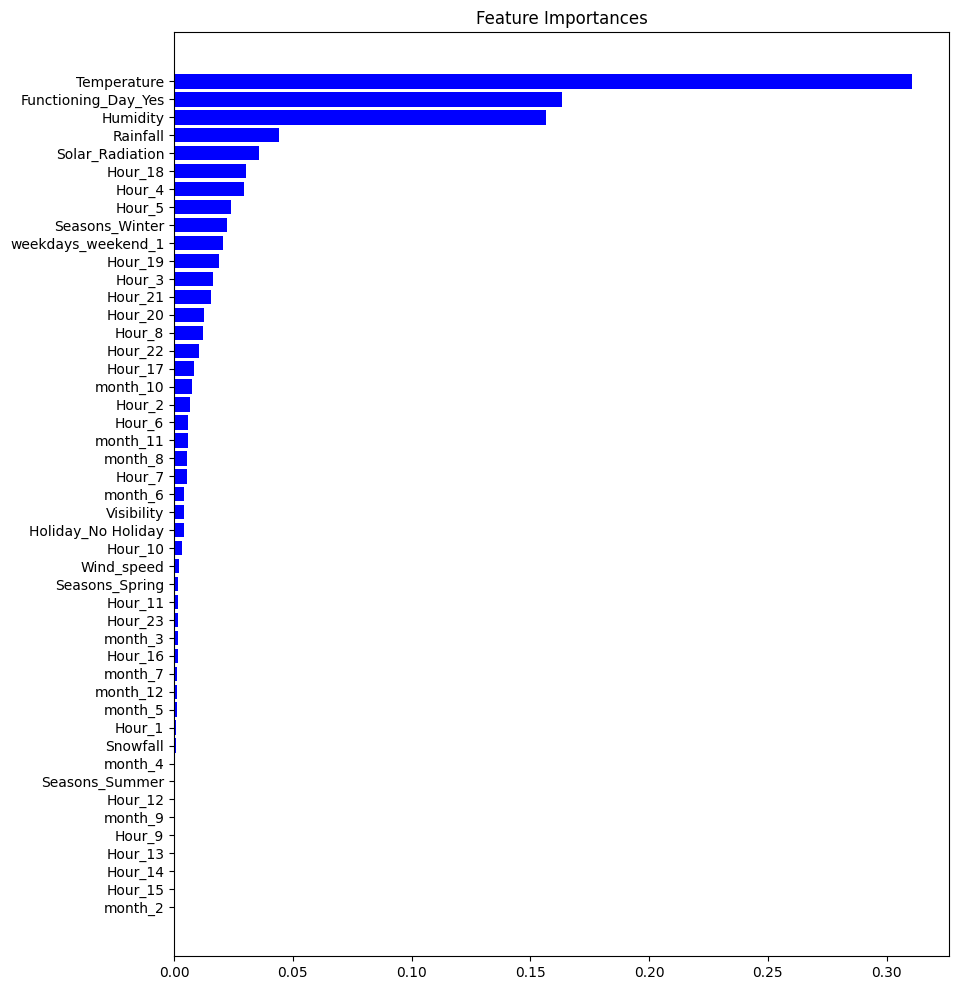

In [339]:
#Plot figure
plt.figure(figsize=(10,12))
plt.yticks(range(len(indices)),[features[i] for i in indices])
plt.title('Feature Importances')
plt.barh(range(len(indices)),importances[indices],color='b',align='center')

####Hyperparameter Tuning

Before proceding further, let's try to tune some hyperparameters and see if the performance of our model improves.

 Hyperparameter tuning is the process of choosing a set of optimal hyperparameters for a leaming algorithm.

  A hyperparameter is a model argument whose value is set before the learning process begins.
  
  The key to machine learning algorithms is hyperparameter tuning.
  
  GridSearchCV: GridSearchCV helps to loop through predefined hyperparameters and fit the model on the training set. So, in the end, we can select the best parameters from the listed hyperparameters.

**Gradient Boosting Regressor with GridSearchCV**

Range of values for chosen hyperparameters.

In [307]:
#Number of trees
n_estimators = [50,80,100]

#Max depth of trees
max_depth = [4,6,8]

#Minimum number of samples required at each leaf node.
min_samples_leaf = [40,50]

#Minimum number of samples required to split a node.
min_samples_split = [50,100,150]

#Hyperparameter grid.
param_dict = {'n_estimators': n_estimators,
               'max_depth': max_depth,
               'min_samples_leaf': min_samples_leaf,
               'min_samples_split': min_samples_split}

In [308]:
param_dict

{'n_estimators': [50, 80, 100],
 'max_depth': [4, 6, 8],
 'min_samples_leaf': [40, 50],
 'min_samples_split': [50, 100, 150]}

Importing Gradient Boosting Regressor.

In [309]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

#Create an instance of GBR
gb_model = GradientBoostingRegressor()

#Grid Search
param_dict = {'learning_rate':[0.1,0.01],
               'n_estimators':[50,100],
               'max_depth':[3,5]}
gb_grid = GridSearchCV(estimator=gb_model,
                       param_grid=param_dict,
                       cv=3,verbose=2,n_jobs=-1)

gb_grid.fit(x_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.1, 0.01], 'max_depth': [3, 5],
                         'n_estimators': [50, 100]},
             verbose=2)

In [310]:
gb_grid.best_estimator_

GradientBoostingRegressor(max_depth=5)

In [311]:
gb_optimal_model = gb_grid.best_estimator_

In [312]:
gb_grid.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}

In [313]:
#Predictions on train and test data
y_pred_train_gb_grid = gb_optimal_model.predict(x_train)
y_pred_test_gb_grid = gb_optimal_model.predict(x_test)

In [314]:
#import libraries
from sklearn.metrics import mean_squared_error

#Calculate MSE
MSE_gb_grid = mean_squared_error(y_train, y_pred_train_gb_grid)
print("MSE:", MSE_gb_grid)

#calulate RMSE
RMSE_gb_grid = np.sqrt(MSE_gb_grid)
print("RMSE:", RMSE_gb_grid)

#calculate MAE
MAE_gb_grid = mean_absolute_error(y_train, y_pred_train_gb_grid)
print("MAE:", MAE_gb_grid)

#import libraries
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_gb_grid = r2_score(y_train, y_pred_train_gb_grid)
print("R2:", r2_gb_grid)
Adjusted_R2_gb_grid = (1 - (1 - r2_score(y_train, y_pred_train_gb_grid)) * ((x_test.shape[0] - 1) / (x_test.shape[0] -x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_gb_grid)

MSE: 9.109607995498802
RMSE: 3.0182127154159963
MAE: 2.1783965311680302
R2: 0.940843120722907
Adjusted R2: 0.9395450939600576


It can be seen that our train set's r2 score value is 0.94 that means our model is able to capture most of the data variance. Lets save it in a dataframe for later comparisons.

In [315]:
#Storing the metrices in a dataframe.
dict1={'Model': 'Gradient Boosting Regression',
        'MSE':round((MSE_gb_grid),3),
        'RMSE':round((RMSE_gb_grid),3),
        'MAE':round((MAE_gb_grid),3),
        'R2':round((r2_gb_grid),3),
        'Adjusted R 2':round((Adjusted_R2_gb_grid),2)}

training_df = pd.concat([training_df, pd.DataFrame([dict1])], ignore_index=True)

In [316]:
from sklearn.metrics import mean_squared_error

#caculate MSE
MSE_gb_grid = mean_squared_error(y_test, y_pred_test_gb_grid)
print("MSE:", MSE_gb_grid)

#calculate RMSE
RMSE_gb_grid = np.sqrt(MSE_gb_grid)
print("RMSE:", RMSE_gb_grid)

#calculate MAE
MAE_gb_grid = mean_absolute_error(y_test, y_pred_test_gb_grid)
print("MAE:", MAE_gb_grid)

#import libraries
from sklearn.metrics import r2_score

#Calculate r2 and adjusted r2_score.
r2_gb_grid = r2_score (y_test, y_pred_test_gb_grid)
print("R2:", r2_gb_grid)
Adjusted_R2_gb_grid = (1 - (1 - r2_score(y_test, y_pred_test_gb_grid)) * ((x_test.shape[0] - 1) / (x_test.shape[0] - x_test.shape[1] - 1)))
print("Adjusted R2:", Adjusted_R2_gb_grid)

MSE: 13.50833320835346
RMSE: 3.6753684452519124
MAE: 2.6316170010326374
R2: 0.9144860367628453
Adjusted R2: 0.9126096799597891


Hyperparameter tunning certainly showed a better result, r2 is 0.91 or test and mae and rmse was lowered. Overall model shows good result.

In [317]:
#Storing test set metrices in a dataframe
dict2 = {
    "Model": "Gradient Boosting Regression",
    "MAE": round(MAE_gb_grid, 3),
    "MSE": round(MSE_gb_grid, 3),
    "RMSE": round(RMSE_gb_grid, 3),
    "R2 score": round(r2_gb_grid, 3),
    "Adjusted R2": round(Adjusted_R2_gb_grid, 2)
}
test_df = pd.concat([test_df, pd.DataFrame([dict2])], ignore_index=True)

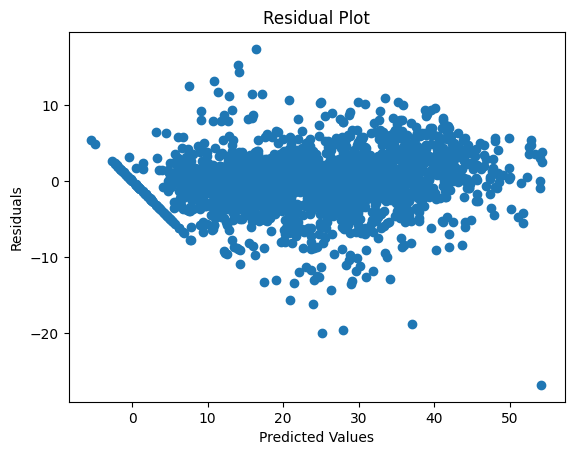

In [318]:
#Heterscadacity
plt.scatter((y_pred_test_gb_grid),(y_test)-(y_pred_test_gb_grid))
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [319]:
gb_optimal_model.feature_importances_

array([3.10732870e-01, 1.56691718e-01, 2.03929245e-03, 4.06186314e-03,
       3.57935109e-02, 4.42562817e-02, 9.26714685e-04, 1.00132162e-03,
       6.79980182e-03, 1.63225131e-02, 2.94736862e-02, 2.38088708e-02,
       5.80604129e-03, 5.25245856e-03, 1.21079095e-02, 1.13420840e-04,
       3.49758696e-03, 1.57374676e-03, 1.44499200e-04, 8.15950195e-05,
       6.88381029e-05, 4.31615993e-05, 1.45305900e-03, 8.34598611e-03,
       3.04295587e-02, 1.88626330e-02, 1.26614174e-02, 1.56649216e-02,
       1.03007874e-02, 1.55299811e-03, 1.64170803e-03, 2.36115485e-04,
       2.22556694e-02, 3.97281911e-03, 1.63391086e-01, 1.54128499e-05,
       1.48838434e-03, 4.03104212e-04, 1.04422428e-03, 4.23386893e-03,
       1.08299786e-03, 5.53243159e-03, 1.27789477e-04, 7.53447090e-03,
       5.64293551e-03, 1.05533600e-03, 2.04725827e-02])

FEATURES STORED

In [320]:
importances = gb_optimal_model.feature_importances_
importance_dict = {
    'Feature': list(x_train.columns),
    'Feature Importance': importances
}
importance_df = pd.DataFrame(importance_dict)

In [321]:
importance_df['Feature Importance']=round(importance_df['Feature Importance'],2)

In [322]:
importance_df.head()

,Feature,Feature Importance
0,Temperature,0.31
1,Humidity,0.16
2,Wind_speed,0.00
3,Visibility,0.00
4,Solar_Radiation,0.04


In [323]:
importance_df.sort_values(by='Feature Importance',ascending=False)

,Feature,Feature Importance
0,Temperature,0.31
34,Functioning_Day_Yes,0.16
1,Humidity,0.16
4,Solar_Radiation,0.04
5,Rainfall,0.04
24,Hour_18,0.03
10,Hour_4,0.03
11,Hour_5,0.02
32,Seasons_Winter,0.02
27,Hour_21,0.02


In [324]:
gb_model.fit(x_train,y_train)

GradientBoostingRegressor()

In [325]:
features = x_train.columns
importances = gb_optimal_model.feature_importances_
indices = np.argsort(importances)

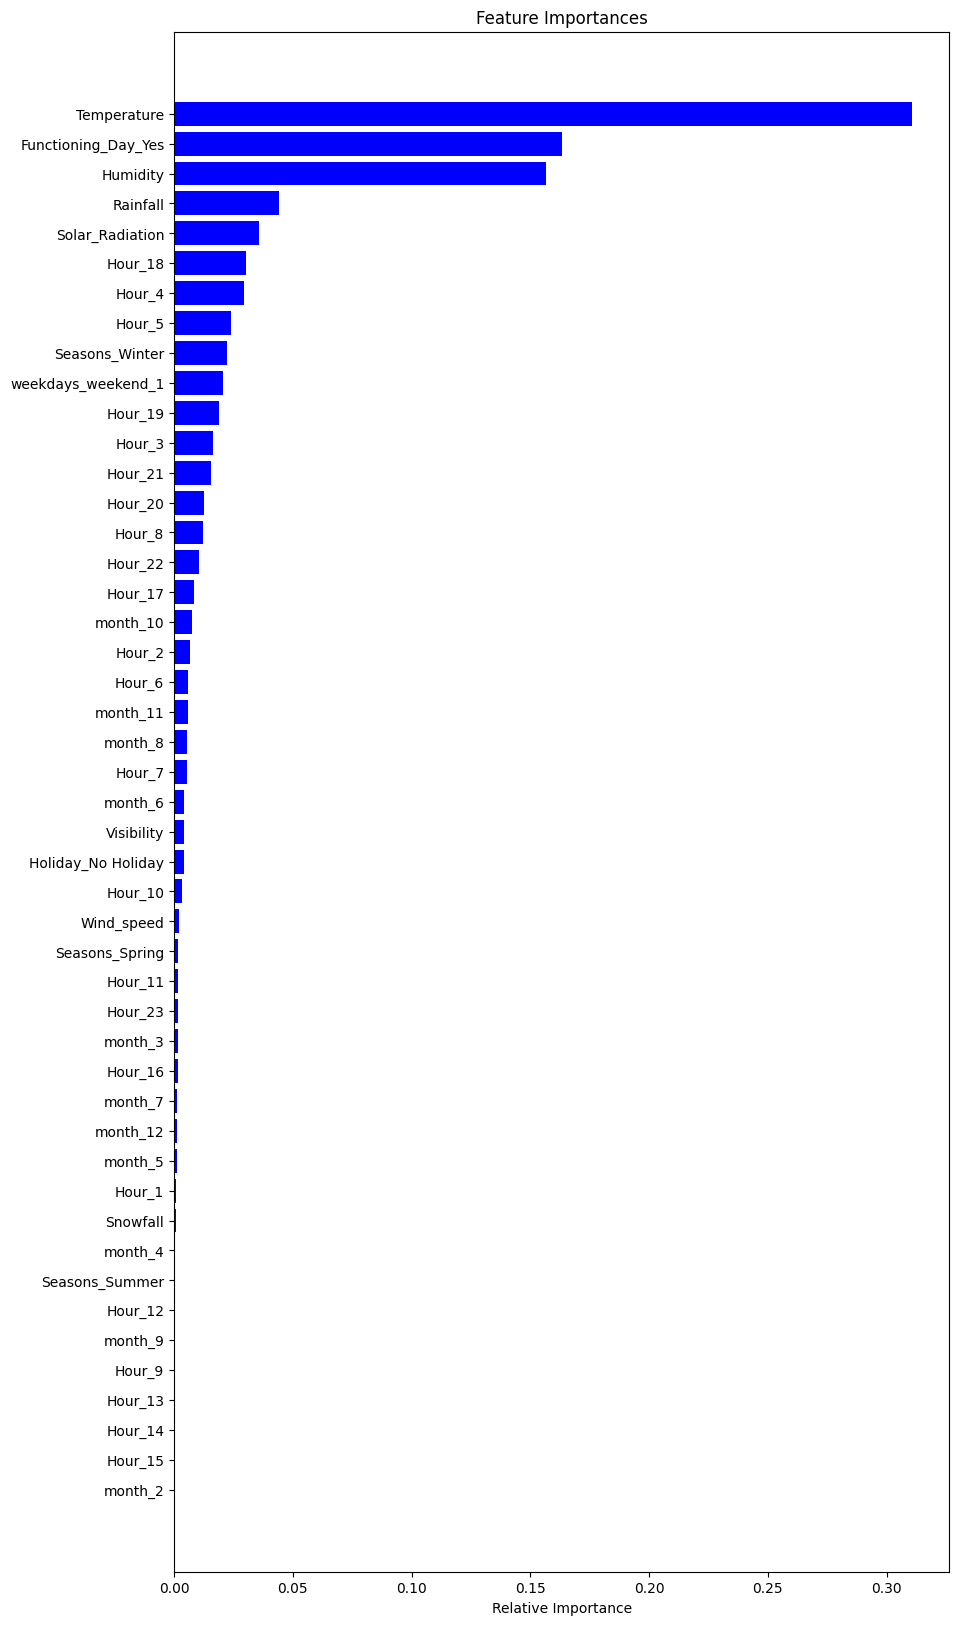

In [326]:
#Figure Plot
plt.figure(figsize=(10,20))
plt.yticks(range(len(indices)),[features[i] for i in indices])
plt.title('Feature Importances')
plt.barh(range(len(indices)),importances[indices],color='b',align='center')
plt.xlabel('Relative Importance')
plt.show()


# **Conclusion**

Our analysis commenced with an exploratory data analysis (EDA) of all dataset features. We focused on our dependent variable, 'Rented Bike Count,' applying transformations when needed. Categorical variables were examined, and those with overwhelming dominance of a single class were discarded. Numerical variables underwent correlation analysis, distribution assessment, and relationship exploration with the dependent variable. Features with predominantly '0' values were removed, and categorical variables were one-hot encoded.

Seven machine learning algorithms were employed: Linear Regression, Lasso, Ridge, Elastic Net, Decision Tree, Random Forest, and Gradient Boosting. Hyperparameter tuning was implemented to optimize model performance. Our model evaluation yielded the following insights:"


In [337]:
#Table including all evaluation metrics used.
result = pd.concat([training_df, test_df],keys=['train','test'])
result

Model     MSE   RMSE    MAE     R2  \
train 0             Linear Regression  32.145  5.670  4.301  0.791   
      1              Lasso Regression  92.646  9.625  7.305  0.398   
      2              Ridge Regression  32.145  5.670  4.301  0.791   
      3         ElasticNet Regression  55.142  7.426  5.653  0.642   
      4      Decision Tree Regression  69.770  8.353  6.061  0.547   
      5      Random Forest Regression   1.577  1.256  0.796  0.990   
      6  Gradient Boosting Regression  19.093  4.370  3.301  0.876   
      7  Gradient Boosting Regression   9.110  3.018  2.178  0.941   
test  0             Linear Regression  31.217  5.587  4.261    NaN   
      1              Lasso Regression  97.803  9.890  7.506    NaN   
      2              Ridge Regression  31.219  5.587  4.261    NaN   
      3      Decision Tree Regression  82.845  9.102  6.562    NaN   
      4      Random Forest Regression  12.642  3.556  2.197    NaN   
      5  Gradient Boosting Regression  21.519  4.639  3.497    NaN   
      6  Gradient Boosting Regression  13.508  3.675  2.632    NaN   

         Adjusted R2  Adjusted R 2  R2 score  
train 0         0.79           NaN       NaN  
      1         0.39           NaN       NaN  
      2         0.79           NaN       NaN  
      3         0.63           NaN       NaN  
      4         0.54           NaN       NaN  
      5         0.99           NaN       NaN  
      6         0.87           NaN       NaN  
      7          NaN          0.94       NaN  
test  0         0.80           NaN     0.802  
      1         0.37           NaN     0.381  
      2         0.80           NaN     0.802  
      3         0.46           NaN     0.476  
      4         0.92           NaN     0.920  
      5         0.86           NaN     0.864  
      6         0.91           NaN     0.914

Gradient Boosting gridsearchcv model shows promising result with R2 score of 0.91, therefore it can be used to solve this problem.

Temperatue, Functioning_Day_Yes, Humidity, Rainfall and Solar radiation are major driving factors for the Bike rent demand.

 Bike demand shows peek around 8-9 AM in the morning and 6-7pm in the evening.

 People prefer to rent bike more in summers than in winters.

  Bike demand is more on clear days than on snowy or rainy days.
  
  The demand for bikes is higher when the temparature ranges between 22 to 25 degree Celcius.


***While the current analysis offers valuable insights, it's crucial to acknowledge the time-dependent nature of the dataset. Variables like temperature, windspeed, and solar radiation may exhibit fluctuations, potentially leading to situations where the model's performance is compromised. Given the dynamic nature of the machine learning field, staying abreast of the latest advancements and preparing for unforeseen challenges is essential. A solid grasp of machine learning concepts will undoubtedly provide a competitive edge in navigating future developments***.


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***